# Data-Driven Analysis of Text-Conditioned AI-Generated Music: A Case Study with Suno and Udio

In [ ]:
import pandas as pd
import numpy as np

from tqdm import tqdm 
tqdm.pandas()

import json

import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from matplotlib import pyplot as plt
import webbrowser
sns.set_theme(style="whitegrid")
COLOR_MAP = {'udio': "#e30b5d", 'suno': "#ffbb30"}

import torch
import torch.nn.functional as F

import umap
import umap.umap_ as umap
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
spc = spacy.load('en_core_web_sm')

# Load JSON Files
We are not providing our collected data.  
To run this notebook and replicate the methods, data should be collected from Suno and Udio using the links we provide and saved in a folder following the pattern: `./jsons/{suno|udio}/metadata/` 

In [ ]:
from multiprocessing import Pool
from tqdm.auto import tqdm
import os
import pandas as pd
import json

def json2df(json_file):
    df = pd.read_json('./jsons/udio/metadata/' + json_file, orient='index').T
    # print(df['lyrics'])
    return df#.astype(str)#[['id', 'title', 'tags','replaced_tags','prompt',]]

filename = './udio_metadata.pkl'
try:
    udio_df = pd.read_pickle(filename)
    print('opening udio_df from pickle')
    print(udio_df.shape)
except:
    print('creating udio_df from json files')
    udio_metadata_files = os.listdir('./jsons/udio/metadata/')
    print(f'metadata files: {len(udio_metadata_files)}')
    ## buggy for some reasons
    # with Pool(1) as p:
    #     udio_dfs = list(tqdm(p.imap(json2df, udio_metadata_files), total=len(udio_metadata_files)))
    udio_dfs = [pd.read_json('./jsons/udio/metadata/' + json_file, orient='index').T for json_file in tqdm(udio_metadata_files)]
    
    udio_df = pd.concat(udio_dfs).reset_index(drop=True)
    # print(udio_df[['lyrics']].head())
    udio_df = udio_df[['id', 'title','lyrics', 'tags','replaced_tags','prompt']]
    udio_df['source'] = 'udio'
    print(f'saving {filename}')
    # udio_df.to_pickle(filename)

udio_df.head()

In [ ]:
from multiprocessing import Pool
from tqdm.auto import tqdm

def json2df(json_file):
    # return pd.read_json('./jsons/suno/metadata/' + json_file, orient='index').T
    df = pd.json_normalize(json.load(open('./jsons/suno/metadata/' + json_file, 'r')))
    # remove 'metadata,' from column names
    df.columns = [col.replace('metadata.', '') for col in df.columns]
    return df

filename = './suno_metadata.pkl'
try:
    print('opening suno_df from pickle')
    suno_df = pd.read_pickle(filename)
    print(suno_df.shape)
except:
    print('creating suno_df from json files')
    suno_metadata_files = os.listdir('./jsons/suno/metadata/')
    print(f'metadata files: {len(suno_metadata_files)}')
    with Pool(16) as p:
        suno_dfs = list(tqdm(p.imap(json2df, suno_metadata_files), total=len(suno_metadata_files)))
    suno_df = pd.concat(suno_dfs).reset_index(drop=True)
    print(suno_df.columns)
    suno_df = suno_df[['id', 'title', 'tags','gpt_description_prompt','prompt']]
    suno_df['source'] = 'suno'
    print(f'saving {filename}')
    suno_df.to_pickle(filename)

suno_df.head()

# Detect Language in Prompts

- We only consider prompts in English
- We use the fasttext language classifier from huggingface

In [ ]:
print("detecting language...")
import fasttext
from huggingface_hub import hf_hub_download

def detect_language(prompt, model):
    # pandas will convert NaN to string "nan"
    if prompt != "nan" and len(prompt) > 0:
        return model.predict(prompt.replace("\n", " "))[0][0].replace("__label__", "")
    else:
        return None

suno_df['gpt_description_prompt'] = suno_df['gpt_description_prompt'].astype(str)
udio_df['prompt'] = udio_df['prompt'].astype(str)

model_path = hf_hub_download(
    repo_id="facebook/fasttext-language-identification", filename="model.bin"
)
model = fasttext.load_model(model_path)
# model.predict(text)[0]
print("classifying Udio prompts")
udio_df["prompt_language"] = udio_df["prompt"].progress_apply(
    lambda x: detect_language(x, model)
)
print("classifying Suno prompts")
suno_df["prompt_language"] = suno_df["gpt_description_prompt"].progress_apply(
    lambda x: detect_language(x, model)
)
    
print('saving suno metadata to pickle')
suno_df.to_pickle("suno_metadata.pkl")

print('saving udio metadata to pickle')
udio_df.to_pickle("udio_metadata.pkl")

In [ ]:
suno_df['prompt_language'].value_counts()

In [ ]:
udio_df['prompt_language'].value_counts()

# Detect Language in Lyrics

- We only consider lyrics in English
- We use the fasttext language classifier from huggingface

In [ ]:
import pandas as pd
# from tqdm import tqdm
# tqdm.pandas()

REDO = True

def detect_language(prompt, model):
    if prompt != 'nan' and len(prompt) > 0:
        return model.predict(prompt.replace("\n", " "))[0][0].replace("__label__", "")
    else:
        return None

suno_df['prompt'] = suno_df['prompt'].astype(str)
udio_df['lyrics'] = udio_df['lyrics'].astype(str)

# check if dataframes contain language column
if "language" in udio_df.columns and "language" in suno_df.columns and REDO==False:
    print("language column exists")
else:
    print("detecting language...")
    import fasttext
    from huggingface_hub import hf_hub_download

    model_path = hf_hub_download(
        repo_id="facebook/fasttext-language-identification", filename="model.bin"
    )
    model = fasttext.load_model(model_path)
    # model.predict(text)[0]
    print("classifying Udio lyrics")
    udio_df["language"] = udio_df["lyrics"].progress_apply(
        lambda x: detect_language(x, model)
    )
    print("classifying Suno lyrics")
    suno_df["language"] = suno_df["prompt"].progress_apply(
        lambda x: detect_language(x, model)
    )
        
    print('saving suno metadata to pickle')
    suno_df.to_pickle("suno_metadata.pkl")

    print('saving udio metadata to pickle')
    udio_df.to_pickle("udio_metadata.pkl")

In [ ]:
language_df = pd.concat(
    [udio_df[["id", "source", "language"]], suno_df[["id", "source", "language"]]]
).reset_index(drop=True)
# language_df = language_df.groupby(['language']).agg({'source':'value_counts'}).unstack(fill_value=0, level=1).sort_values(by=('source','suno'), ascending=False)

lang_counts = language_df[['language','source']].value_counts().reset_index()
udio_total = lang_counts[lang_counts['source']=='udio']['count'].sum()
suno_total = lang_counts[lang_counts['source']=='suno']['count'].sum()

lang_counts['percentage'] = lang_counts.apply(lambda x: x['count']/udio_total*100 if x['source']=='udio' else x['count']/suno_total*100, axis=1)
print(lang_counts.head(15))

top_langs = lang_counts.groupby('language').sum().sort_values('count', ascending=False)
print("\nTop Languages:\n", top_langs.head(15))
top_langs = top_langs.reset_index()['language']

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
pd.merge(
    left=lang_counts[(lang_counts['source']=='udio') & (lang_counts['language'].isin(top_langs[:15]))],
    right=lang_counts[(lang_counts['source']=='suno') & (lang_counts['language'].isin(top_langs[:15]))],
    on='language', 
    suffixes=('_udio', '_suno'),
    how='outer'
    ).fillna(0).set_index('language')[['percentage_udio', 'percentage_suno']].loc[top_langs[:15]]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    kind="bar",
    orient="h",
    # data=language_df[language_df["language"].isin(top_langs)], 
    data = lang_counts[lang_counts['language'].isin(top_langs[:15])],
    y="language",
    x="percentage", 
    hue="source",
    # col="source",
    # palette='Set2',
    palette=["#e30b5d", "#ffbb30"],
    hue_order=["udio","suno"],
    saturation=1.0,
    # stat='percent',
    # height=5, 
    aspect=1,
    order=top_langs[:15],
    # width=0.9,
    # legend=True,
    )

plt.show()

In [ ]:
lang_list = lang_counts['language'].unique()
lang_palette = sns.color_palette("Set2", len(lang_list))
lang_colors = dict(zip(lang_list, lang_palette))

sns.set_context('paper')
sns.set_style('whitegrid')

for s in ['suno', 'udio']:
    df = suno_df if s == 'suno' else udio_df
    g = sns.catplot(
        kind='count',
        data=df,
        x="language",
        # stat='percent',
        order=df["language"].value_counts().iloc[:15].index,
        height=4, 
        aspect=3,
        hue='language',
        palette=lang_colors,
        saturation=1.0,
        legend=False,
        ).set_xticklabels(rotation=45).set_axis_labels("Language", "Percentage of Prompts")

    # extract the matplotlib axes_subplot objects from the FacetGrid
    ax = g.facet_axis(0, 0)  # or ax = g.axes.flat[0]
    ax.set_title(f"Language Distribution of Prompts ({s.capitalize()})")

    plt.show()

# Prompts

- Prompts are loaded and filtered by language and length
- Duplicates are dropped to avoid skewing clustering with repeated songs (some users will create multiple version of the same song)
- Textual Embeddings are computed using `NV-Embed-v2`
    - we used the 4bit quantized version 
    - we also compute a selfsimilarity matrix to find close elements if necessary
- We use UMAP to reduce the embeddings to 5 dimensions
- We cluster elements in this space using HDBSCAN
- We reduce the original space down to 2 dimensions for visualization

In [ ]:
def cluster_prompts_bow(column_name, df, top_k=3, verbose=False):
        cluster_names = {}
        for label in tqdm(df[column_name].value_counts().index):
            if verbose: print(f"Cluster {label}")
            if label == '-1':
                cluster_names[label] = 'outliers'
                continue
            else:
                lyrics = []
                for doc in spc.pipe(df[df[column_name] == label]['prompt'], disable=['ner', 'parser', 'textcat', 'word2vec']):
                    lyrics.append(" ".join(token.lemma_ for token in doc))
                
                if verbose: print(len(lyrics))
                
                # do tfidf vectorization
                vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,1))
                X = vectorizer.fit_transform(lyrics)
                word_freq = Counter(dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)))
                top3 = word_freq.most_common(top_k)
                if verbose: print(top3)
                cluster_names[label] = '_'.join([t[0] for t in top3])
                
        return cluster_names

In [ ]:
!rm ./prompts_nvemb_hdb.pkl
try:
    # raise Exception("force reload")
    X = pd.read_pickle("./prompts_nvemb_hdb.pkl")
    X = X[X['prompt_language'].str.startswith("eng")]
    X['hdb_label'] = X['hdb_label'].astype(int)
    print(X.shape)
    X = X.drop_duplicates(subset=['prompt'])
    print(X.shape)
    suno_df = pd.read_pickle("suno_metadata.pkl")
    suno_df["source"] = "suno"
    udio_df = pd.read_pickle("udio_metadata.pkl")
    udio_df["source"] = "udio"
    X = X.merge(pd.concat([udio_df, suno_df]), on="id", how="left", suffixes=('', '_y'))
    print(X.shape)
    print(X.columns)
    
except:
    suno_df = pd.read_pickle("suno_metadata.pkl")
    suno_df["source"] = "suno"
    udio_df = pd.read_pickle("udio_metadata.pkl")
    udio_df["source"] = "udio"
    # nltk.download('punkt_tab')
    # nltk.download('stopwords')

    #%% load data
    print("metadata loaded")
    print(f"udio rows: {len(udio_df)}")
    print(f"suno rows: {len(suno_df)}")
    print(f"total rows: {len(udio_df) + len(suno_df)}")

    #%%
    udio_prompts = udio_df[["id", "source", "title","prompt", "language", 'prompt_language']].dropna(subset=["prompt"])
    suno_prompts = suno_df[["id", "source","title","gpt_description_prompt", "language", 'prompt_language'
                            ]].dropna(subset=["gpt_description_prompt"]).rename(columns={"gpt_description_prompt": "prompt"})

    # merge them and assign them a source column
    prompts = pd.concat([udio_prompts, suno_prompts])
    prompts = prompts.dropna(subset=["language"])
    prompts = prompts[prompts['language'].str.startswith("eng") & prompts['prompt_language'].str.startswith("eng") ]
    prompts = prompts[
        (prompts['prompt'].str.len() < 1230) & 
        (prompts['prompt'].str.len() > 0)
        ]
    print(f"total prompts: {len(prompts)}")
    print(prompts.columns)

    X = prompts #.sample(5000)

    #%%
    from transformers import BitsAndBytesConfig, AutoModel
    from torch import float16
    from torch.nn import functional as F
    import os

    os.environ['TOKENIZERS_PARALLELISM'] = "false"

    # quantization_config = BitsAndBytesConfig(
    #     load_in_4bit=True,
    #     bnb_4bit_compute_dtype=float16
    #     )
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True, 
        bnb_4bit_quant_type="nf4", 
        bnb_4bit_use_double_quant=True, 
        bnb_4bit_compute_dtype=torch.bfloat16,
        )

    # load model with tokenizer
    model = AutoModel.from_pretrained(
        'nvidia/NV-Embed-v2', 
        trust_remote_code=True,
        device_map="cuda",
        quantization_config=quantization_config
        # use_8bit=True,
        )

    # df['len_tok'] = df['lyrics'].apply(lambda x: len(model.tokenizer.encode(x)))
    # df = df[df['len_tok'] <= 5000]

    # emb = model.encode(lyrics, instruction="", max_length=max([len(l) for l in lyrics]))
    emb = model._do_encode(
        # model.tokenizer.encode(X['prompt'].values.tolist()).to('cuda', dtype=torch.bfloat16),
        X['prompt'].values.tolist(),
        batch_size=16, 
        instruction="", 
        max_length=500, 
        num_workers=16, 
        return_numpy=False
        )
    emb = F.normalize(emb, p=2, dim=1).detach().to('cpu').numpy()

    X['emb'] = emb.tolist()

    X.to_pickle("prompts_nvemb_embeddings.pkl")

In [ ]:
print("umap 5d")
reducer = umap.UMAP(
        n_jobs=32, 
        n_neighbors=15,
        min_dist=0.15,
        n_components=5,
        metric="cosine",
        # random_state=42, #fixing seed turns off parallelization
    )

X_embedded = reducer.fit_transform(X['emb'].apply(np.array).values.tolist())
print(X_embedded.shape)

for component in range(X_embedded.shape[1]):
    X[f'umap_d{component}'] = X_embedded[:,component]

In [ ]:
#%%
from sklearn.cluster import HDBSCAN

print("clustering")
hdb = HDBSCAN(
    n_jobs=32,
    min_cluster_size=20,
    cluster_selection_method='eom',
    min_samples=20,
    max_cluster_size=250,
    cluster_selection_epsilon=0.25,
)


X['hdb_label'] = hdb.fit_predict(X_embedded)
X['hdb_label'] = X['hdb_label'].astype(str)
# X['hdb_label'].value_counts().reset_index()
# cluster_names = cluster_bow(X, 'hdb_label',top_k=3, verbose=False)
cluster_names = cluster_prompts_bow('hdb_label', X, top_k=3, verbose=False)
X['hdb_names'] = X['hdb_label'].apply(lambda x: cluster_names[x])
X[['hdb_names', 'hdb_label']].value_counts().reset_index()


In [ ]:
import umap.umap_ as umap
print("umap 2d")
reducer = umap.UMAP(
        n_jobs=40,
        n_neighbors=25,
        min_dist=0.65,
        n_components=2,
        metric="cosine",
        # random_state=42,
    )

umap2d = reducer.fit_transform(X['emb'].apply(np.array).values.tolist(), y=X['hdb_label'])
X['umap_x'] = umap2d[:,0]
X['umap_y'] = umap2d[:,1]


In [ ]:
#%%
print("plotting")
cluster_names = {k:v for k,v in X[['hdb_label', 'hdb_names']].values}

scatter = px.scatter(
    X, 
    x="umap_x", 
    y="umap_y", 
    # size = "total", 
    # size = round(np.sqrt(X['total'])),
    color="hdb_names",
    # color_discrete_sequence=px.colors.qualitative.Set2,
    color_discrete_map={"-1":"white", "outliers":"white"},
    # rename labels in legend
    hover_data=["id", "source", "prompt", "hdb_label","title"], 
    category_orders = {"hdb_names": X[['hdb_names', 'hdb_label']].value_counts().reset_index()['hdb_names'].values.tolist()}
    )


fig = go.FigureWidget(layout={'hovermode': 'closest'})
fig.update_layout(width=1600, height=1200)
fig.add_traces(scatter.data)
# fig.update_traces(marker=dict(opacity=0.25))
fig.update_layout(
title="HDBSCAN clusters of prompts embeddings (NV-Embed)",
)

def do_click(trace, points, state):
    if points.point_inds:
        ind = points.point_inds[0]
        # print('ind',ind)
        point_id = trace.customdata[ind][0]
        source = trace.customdata[ind][1]
        print(point_id, source)
        if source == 'suno':
            url = "https://www.suno.com/song/" + point_id
        elif source == 'udio':
            url = "https://www.udio.com/songs/" + point_id
        display(url)
        print(url)
        webbrowser.open_new_tab(url)
[s.on_click(do_click) for s in fig.data]


# for each cluster add centroid with name
# should be on top of the points and not appear in the legend
for label in X['hdb_label'].unique():
    if label == '-1':
        continue
    centroid = X[X['hdb_label'] == label][['umap_x','umap_y']].median()
    fig.add_trace(go.Scattergl(
        x=[centroid['umap_x']],
        y=[centroid['umap_y']],
        mode='text',
        marker=dict(size=12, color='black', symbol='x'),
        text=[cluster_names[label]],
        textposition="top center",
        showlegend=False,
        # zorder=999
    ))



# fig.write_image("./figs/prompts_nvemb_hdb.png")
X.to_pickle("prompts_nvemb_hdb.pkl")
# X[["id","source","prompt","hdb_label","hdb_names","umap_x","umap_y","title"]].to_json('./dash_server/dash_prompts.json', orient='records')

fig#.show()

# Lyrics

- Lyrics are loaded and filtered by language and length
- Duplicates are dropped to avoid skewing clustering with repeated songs (some users will create multiple version of the same song)
- Textual Embeddings are computed using `NV-Embed-v2`
    - we used the 4bit quantized version 
    - we also compute a selfsimilarity matrix to find close elements if necessary
- We use UMAP to reduce the embeddings to 5 dimensions
- We cluster elements in this space using HDBSCAN
- We reduce the original space down to 2 dimensions for visualization

## Load data

In [ ]:
import pandas as pd
import os

REDO = True

if os.path.exists('lyrics_combined.pkl') and not REDO:
    df = pd.read_pickle('lyrics_combined.pkl')
else:
    print('Selecting only songs with english language')
    print('---')

    suno_df = pd.read_pickle("suno_metadata.pkl").dropna(subset=['language'])
    suno_df = suno_df[suno_df['language'].str.startswith('eng_')]
    # suno_df = suno_df.drop_duplicates(subset=['prompt'])
    print(f"Number of English Suno songs: {len(suno_df)}")

    udio_df = pd.read_pickle("udio_metadata.pkl").dropna(subset=['language'])
    udio_df = udio_df[udio_df['language'].str.startswith('eng_')]
    # udio_df = udio_df.drop_duplicates(subset=['lyrics'])
    print(f"Number of English Udio songs: {len(udio_df)}")


    print(f"merging datasets")
    df1 = suno_df[['id','prompt','source','tags','title']].rename(columns={'prompt':'lyrics'})
    df2 = udio_df[['id','lyrics','source','tags','title']]
    df = pd.concat([df1,df2]).reset_index(drop=False)
    print('df shape:',df.shape)
    df['length'] = df['lyrics'].apply(len)
    print('length filtered to [20, 3600]')
    df = df[
        (df['length'] > 20 ) &
        (df['length'] < 3_600)
        ]
    print('dropping duplicates')
    df.drop_duplicates(subset=['lyrics'], inplace=True)
    df.reset_index(drop=True).to_pickle('lyrics_combined.pkl')

df.head()

## Compute embeddings and self-similarity

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from transformers import BitsAndBytesConfig
import numpy as np

if 'emb' in df.columns:
    emb = np.array([np.array(x) for x in df['emb'].values])
else:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16
        )

    # load model with tokenizer
    model = AutoModel.from_pretrained(
        'nvidia/NV-Embed-v2', 
        trust_remote_code=True,
        quantization_config=quantization_config
        )

    # df['len_tok'] = df['lyrics'].apply(lambda x: len(model.tokenizer.encode(x)))
    # df = df[df['len_tok'] <= 10_000]

    # emb = model.encode(lyrics, instruction="", max_length=max([len(l) for l in lyrics]))
    emb = model._do_encode(
        # df['lyrics'].values.tolist(),
        ('Title: ' + df['title'] + '\n\n' + df['lyrics']).values.tolist(),
        batch_size=8, 
        instruction="", 
        max_length=3700, # +100 to account for title? also this is probably in tokens not chars 
        num_workers=32, 
        return_numpy=False
        )
    emb = F.normalize(emb, p=2, dim=1).to('cpu').numpy()
    # emb.shape, df.shape
    df['emb'] = emb.tolist()
    # df.head(5)
    df.to_pickle('lyrics_combined.pkl')

if os.path.exists('selfsim.npy'):
    selfsim = np.load('./selfsim.npy')
else:
    selfsim = (emb @ emb.T) * 100
    np.save('./selfsim.npy', selfsim, allow_pickle=True)

### Find similar songs in embeddings space

In [ ]:
import numpy as np

def find_similar(idx, df, selfsim, show_lyrics=False, show_links=False):
    if df.iloc[idx].source == 'suno':
        link = f"https://www.{df.iloc[idx].source}.com/song/{df.loc[idx].id}"
    else:
        link = f"https://www.{df.iloc[idx].source}.com/songs/{df.loc[idx].id}"
        
    print(f"analyzing song {idx} ({link})\n---")

    top5 = np.argsort(selfsim[idx])[::-1][1:6]
    top5 = {i: selfsim[idx][i] for i in top5}
    # top5_idx = list(top5.keys())
    
    for k,v in top5.items():
        if show_links == False:
            print(f"Song:\t{k}\tsim: {v:.2f}")
        elif show_links == True:
            if df.iloc[k].source == 'suno':
                link = f"https://www.{df.iloc[k].source}.com/song/{df.loc[k].id}"
            else:
                link = f"https://www.{df.iloc[k].source}.com/songs/{df.loc[k].id}"
            print(f"Song:\t{k}\tsim: {v:.2f}\tURL:{link}")
    
    if show_lyrics:
        print('showing lyrics for most similar')
        print(f'----- Song {idx} -----')
        print(
            df.loc[idx].lyrics
        )

        most_similar = max(top5, key=top5.get)
        print(f'----- Song {most_similar} -----')
        print(
            df.loc[most_similar].lyrics
        )
        
    return 

In [ ]:
find_similar(
    df[(df['source'] == 'suno') & (df['index'] == 0)].index[0], 
    df, 
    selfsim, 
    show_lyrics=False,
    show_links=True,
    )

## Dimensionality reduction and clustering

In [ ]:
import re
import pandas as pd
import os

if os.path.exists('lyrics_df.pkl'):
    lyrics_df = pd.read_pickle('lyrics_df.pkl')
    cluster_names = {label:name for name,label in lyrics_df[['hdb_names','hdb_label']].values}
else:
    # remove ctrl seqs between square brackets
    df['lyrics'] = df['lyrics'].apply(lambda x: re.sub(r'\[.*?\]', '', x))
    df['lyrics'] = df['lyrics'].apply(str.strip)
    lyrics_df = df[df['lyrics'].str.len() > 1].copy() #.sample()

emb = lyrics_df['emb'].values.tolist()

lyrics_df.head(5)

### UMAP

In [ ]:
# plot using umap
# import umap
import umap.umap_ as umap

reducer = umap.UMAP(
        # n_neighbors=50,
        # min_dist=0.15,
        n_components=5,
        metric="cosine",
        # random_state=42, #fixing seed turns off parallelization
        n_jobs=40, 
    )

for dim, component in enumerate( reducer.fit_transform(emb).T):
    lyrics_df[f'umap_d{dim}'] = component

### HBSCAN Clustering

In [ ]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(
    # min_samples=3,
    # min_cluster_size=20,
    cluster_selection_method='eom',
    # max_cluster_size=200,
    # cluster_selection_epsilon=0.3,
    n_jobs=40,
)

lyrics_df['hdb_label'] = hdb.fit_predict(lyrics_df[[col for col in lyrics_df.columns if col.startswith('umap_d')]])
lyrics_df['hdb_label'] = lyrics_df['hdb_label'].astype(str)
lyrics_df['hdb_label'].value_counts().reset_index()

### Naming clusters

In [ ]:
#import counter
from collections import Counter
from tqdm.auto import tqdm
# import nltk
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
spc = spacy.load('en_core_web_sm')

# nltk.download('punkt_tab')
# nltk.download('stopwords')

def cluster_lyrics_bow(column_name, df, top_k=3, verbose=False):
    cluster_names = {}
    for label in tqdm(df[column_name].value_counts().index):
        if verbose: print(f"Cluster {label}")
        if label == '-1':
            cluster_names[label] = 'outliers'
            continue
        else:
            lyrics = []
            for doc in spc.pipe(df[df[column_name] == label]['lyrics'], disable=['ner', 'parser', 'textcat', 'word2vec']):
                lyrics.append(" ".join(token.lemma_ for token in doc))
            
            if verbose: print(len(lyrics))
            
            # do tfidf vectorization
            vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,1))
            X = vectorizer.fit_transform(lyrics)
            word_freq = Counter(dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)))
            top3 = word_freq.most_common(top_k)
            if verbose: print(top3)
            cluster_names[label] = '_'.join([t[0] for t in top3])
            
    return cluster_names

cluster_names = cluster_lyrics_bow('hdb_label',lyrics_df,top_k=3, verbose=False)
lyrics_df['hdb_names'] = lyrics_df['hdb_label'].apply(lambda x: cluster_names[x])
lyrics_df[['hdb_names', 'hdb_label']].value_counts().reset_index()

### Save precomputed dataframe

In [ ]:
lyrics_df.to_pickle('lyrics_df.pkl')

## Plot


In [ ]:
import pandas as pd

lyrics_df = pd.read_pickle('lyrics_df.pkl')
emb = lyrics_df['emb'].values.tolist()

### 2D UMAP

In [ ]:
# import umap
import umap.umap_ as umap

reducer = umap.UMAP(
        n_neighbors=75,
        min_dist=0.25,
        n_components=2,
        metric="cosine",
        # random_state=42,
        n_jobs=40,
    )

X_embedded = reducer.fit_transform(emb, y=lyrics_df['hdb_label'])

lyrics_df['umap_x'] = X_embedded[:,0]
lyrics_df['umap_y'] = X_embedded[:,1]

### Scatterplot with plotly

In [ ]:
import pandas as pd
import numpy as np

import webbrowser
import plotly.express as px
import plotly.graph_objects as go
from IPython import display

# lyrics_df = pd.read_json('../../dash_server/dash_lyrics.json').sample(1000)
print(lyrics_df.shape)

cluster_names = { label: name for name, label in lyrics_df[['hdb_names', 'hdb_label']].values}

scatter = px.scatter(
    lyrics_df,
    x="umap_x",
    y="umap_y",
    color="hdb_names",
    # symbol="source", symbol_map={"suno":"circle","udio":"star-triangle-up"},
    color_discrete_map={'outliers': 'white'},
    hover_data=["id", "source",'title'],
    title="NV-EMBEDv2 lyrics embeddings + HDBSCAN",
    render_mode='webgl',
)
# scatter.show()

fig = go.FigureWidget(layout={'hovermode': 'closest'})
fig.add_traces(scatter.data)
fig.for_each_trace(lambda t: 
    # print(t)
    t.update(marker={
    'opacity' : 0.2 if t['name'] == 'outliers' else 0.4,
    'color' : '#ddd' if t['name'] == 'outliers' else t['marker']['color'],
    'line': {'color': 'grey', 'width': 0.5} if t['name'] == 'outliers' else t['marker']['line'],
    'size': 8
    })
)


def do_click(trace, points, state):
    if points.point_inds:
        ind = points.point_inds[0]
        # print('ind',ind)
        point_id = trace.customdata[ind][0]
        source = trace.customdata[ind][2]
        if source == 'suno':
            url = "https://www.suno.com/song/" + point_id
        else:
            url = "https://www.udio.com/songs/" + point_id
        # display(url)
        print(url)
        webbrowser.open_new_tab(url)
[s.on_click(do_click) for s in fig.data]

## for each cluster add centroid with name
## should be on top of the points and not appear in the legend
for label in lyrics_df['hdb_label'].unique():
    if label == '-1':
        continue
    centroid = lyrics_df[lyrics_df['hdb_label'] == label][['umap_x','umap_y']].mean()
    fig.add_trace(go.Scattergl(
        x=[centroid['umap_x']],
        y=[centroid['umap_y']],
        mode='text',
        marker=dict(size=12, color='black', symbol='x'),
        text= cluster_names[label].split('/')[-1],
        textposition="middle center",
        showlegend=False,
        # zorder=999
    ))
    
    

fig.update_layout(
    # margin=dict(l=0, r=0, t=0, b=0),
    # title=None,
    width=1600, height=800,
    # showlegend=False,
)
# fig.update_xaxes(visible=False, range=[-1.25, 11.25])
# fig.update_yaxes(visible=False, range=[0.25, 13.00])
# fig.update_traces(textfont_size=20)
# # fig.write_image('./figs/lyrics_clean_2x1.pdf')

# fig.update_layout(plot_bgcolor='white')

fig.show()


### 3D version

In [ ]:
reducer = umap.UMAP(
        n_neighbors=50,
        min_dist=0.5,
        n_components=3,
        metric="cosine",
        n_jobs=40,
    )

X_embedded = reducer.fit_transform(emb, y=lyrics_df['hdb_label'])

lyrics_df['umap_3dx'] = X_embedded[:,0]
lyrics_df['umap_3dy'] = X_embedded[:,1]
lyrics_df['umap_3dz'] = X_embedded[:,2]

In [ ]:
# import pandas as pd
# lyrics_df = pd.read_pickle('lyrics_df.pkl')

import webbrowser
import plotly.express as px
import plotly.graph_objects as go
from IPython import display

def do_click(trace, points, state):
    if points.point_inds:
        ind = points.point_inds[0]
        # print('ind',ind)
        point_id = trace.customdata[ind][0]
        # print(point_id)
        if trace.customdata[ind][1].source == 'suno':
            url = "https://www.suno.com/song/" + point_id
        else:
            url = "https://www.udio.com/songs/" + point_id
        # display(url)
        print(url)
        webbrowser.open_new_tab(url)

scatter = px.scatter_3d(
    lyrics_df,
    x="umap_3dx",
    y="umap_3dy",
    z="umap_3dz",
    color="hdb_names",
    # symbol="source", symbol_map={"suno":"circle","udio":"star-triangle-up"},
    color_discrete_map={'outliers': 'white'},
    width=1200, height=800,
    hover_data=["id", "index", "source",'title'],
    title="NV-EMBEDv2 lyrics embeddings + HDBSCAN",
    
).data

fig = go.FigureWidget(layout={'hovermode': 'closest'})
fig.update_layout(title='NV-EMBEDv2 lyrics embeddings + HDBSCAN')
fig.update_layout(width=1600, height=900)
fig.add_traces(scatter)
fig.update_traces(marker=dict(size=2.5, opacity=0.35))
[s.on_click(do_click) for s in fig.data]

# for each cluster add centroid with name
# should be on top of the points and not appear in the legend
for label in lyrics_df['hdb_label'].unique():
    if label == '-1':
        continue
    centroid = lyrics_df[lyrics_df['hdb_label'] == label][['umap_3dx','umap_3dy','umap_3dz']].mean()
    fig.add_trace(go.Scatter3d(
        x=[centroid['umap_3dx']],
        y=[centroid['umap_3dy']],
        z=[centroid['umap_3dz']],
        mode='text',
        marker=dict(size=10, color='black', symbol='x'),
        text=[cluster_names[label]],
        textposition="top center",
        showlegend=False,
        # zorder=999
    ))

fig
# umap.plot.points(reducer, labels=lyrics_df['hdb_names'], width=1000, height=1000, color_key_cmap='tab20')

## Find 5 songs closest to each centroid

In [ ]:
import pandas as pd

lyrics_df = pd.read_pickle('lyrics_df.pkl')

In [ ]:
lyrics_df[['hdb_names','hdb_label']].value_counts().to_csv('cluster_counts.csv')

In [ ]:
import numpy as np

clusters = lyrics_df[['hdb_label','hdb_names']].value_counts().index.to_list()
centroids = lyrics_df.groupby('hdb_names')[['umap_d0','umap_d1','umap_d2','umap_d3','umap_d4']].mean()


with open("top5_clusters.txt","w") as f:
    strings = []
    for label,cluster in clusters:
        if cluster == 'outliers':
            continue
        centroid = centroids.loc[cluster].tolist()
        # print(f"Centroid: {centroid}")
        songs = lyrics_df[lyrics_df['hdb_names'] == cluster][['title','source','id']]
        # distance to centroid
        songs['dist2ctrd'] = songs.apply(lambda x: np.linalg.norm(centroid - lyrics_df.loc[x.name][['umap_d0','umap_d1','umap_d2','umap_d3','umap_d4']]), axis=1)
        top_5 = songs.sort_values('dist2ctrd').reset_index().head(5)
        
        strings.append(f"Cluster: {label} - {cluster}\n")
        
        # iterate top 5 and create urls
        for idx, song in top_5.iterrows():
            if song.source == 'suno': url = f"https://www.suno.com/song/{song.id}"
            elif song.source == 'udio': url = f"https://www.udio.com/songs/{song.id}"
            strings.append(f"{idx+1}) dist: {song.dist2ctrd:.2e} - {url}\n")
        strings.append("\n")
    f.writelines(strings)
        

# Tags (redone)

In [ ]:
import pandas as pd 
import re
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import rapidfuzz
from collections import Counter


tqdm.pandas()

In [ ]:
tags_df = pd.read_pickle('lyrics_combined.pkl')[['id','tags','source']].dropna()

In [ ]:
suno_tags = tags_df[tags_df['source'] == 'suno']
udio_tags = tags_df[tags_df['source'] == 'udio']

In [ ]:
udio_tags[["hopeful,epic" in tags for tags in udio_tags['tags']]]

,id,tags,source
47735,438f92d0-8343-432f-b1da-e635bff04d06,"[symphonic metal, power metal, energetic, hope...",udio


In [ ]:
tags_df.loc[47735].tags

['symphonic metal',
 'power metal',
 'energetic',
 'hopeful,epic',
 'passionate',
 'uplifting',
 ' male vocalist']

In [ ]:
udio_tags_list = []
udio_tags['tags'].progress_apply(lambda x: udio_tags_list.extend(x))
udio_tags_list = [t.lower().strip() for t in udio_tags_list]
udio_tags_list = [t for t in udio_tags_list if len(t) > 1]
udio_tags_count = Counter(udio_tags_list)
udio_tags_count = pd.DataFrame.from_dict(udio_tags_count, orient='index', columns=['count']).reset_index().rename(columns={'index':'tag'})
udio_tags_count['length'] = udio_tags_count['tag'].apply(len)
udio_tags_count = udio_tags_count.sort_values('length', ascending=False)
udio_tags_count

  0%|          | 0/12732 [00:00<?, ?it/s]

,tag,count,length
6426,craft an electronic symphony / blend shimmerin...,1,1253
4136,making the vocals clearer and creating a large...,1,1042
5953,piano and violin. use this lyric\ni've been dr...,1,1006
7501,male vcalist (person a: deep smooth husky voi...,1,750
6381,[vocalist ahri: ahri's singing voice is powerf...,1,668
...,...,...,...
2679,mc,2,2
2908,f#,1,2
7449,fx,1,2
3568,vs,1,2


In [ ]:
print(f"Percentage of audio tags that appear less than 10 times")
print(f"{(udio_tags_count[udio_tags_count['count'] < 10]['count'].sum() / udio_tags_count['count'].sum() * 100):.2f}%")

Percentage of audio tags that appear less than 10 times
9.33%


In [ ]:
def tags_string2list(tags_vocab, string, verbose=False):
    splits = []
    string = " " + string.lower() + " "
    # iter the vocab and look for matches
    # matched tags will be removed from the string
    # upon matching restart the loop
    # if no matches by the end of the loop, return the splits
    while True:
        matched = False
        if verbose: print(f">>{string}")
        for v in tags_vocab:
            if f" {v} " in string:
                # print(">>>", string)
                if verbose: print(f"Matched by substring: {v}")
                # remove v from string
                splits.append(v)
                new_string = string.replace(f"{v} ", ' ')
                # new_string = new_string.strip()
                # print(new_string)
                string = new_string
                matched = True
                break
        if not matched:
            if string != '':
                if verbose: print(f"No match found for remaining string: {string}")
            break
    return splits

In [ ]:
udio_vocab = udio_tags_count[udio_tags_count['count'] > 5]['tag'].tolist()
# udio_vocab

suno_tags['tags'].sample(5).apply(lambda x: tags_string2list(udio_vocab, x,verbose=True))

>> pop motivational 
Matched by substring: pop
>>  motivational 
No match found for remaining string:   motivational 
>> eurobeat, hi-nrg, italo disco 
Matched by substring: disco
>> eurobeat, hi-nrg, italo  
No match found for remaining string:  eurobeat, hi-nrg, italo  
>> experimental electronica, post-industrial 
Matched by substring: post-industrial
>> experimental electronica,  
Matched by substring: experimental
>>  electronica,  
No match found for remaining string:   electronica,  
>> ambient techno 
Matched by substring: ambient techno
>>  
No match found for remaining string:   
>> soulful, melodic, with female vocals 
Matched by substring: female vocals
>> soulful, melodic, with  
Matched by substring: melodic,
>> soulful,  with  
No match found for remaining string:  soulful,  with  


7606                               [pop]
16224                            [disco]
26101    [post-industrial, experimental]
22865                   [ambient techno]
6135           [female vocals, melodic,]
Name: tags, dtype: object

In [ ]:
import re

# match things that look like a list: e.g. (\w[,|;])+\w
def is_list_string(s):
    return bool(re.search(r"(\w[,|;|\.|\n]\s)+\w", s.lower()))

suno_tags['is_list'] = suno_tags['tags'].apply(is_list_string)

suno_tags[suno_tags['is_list'] == True]

# x = suno_tags.sample(1).tags.values[0]
# print(x)
# print(re.split(r"[,|;|\.|\n]\s*", x))

/tmp/ipykernel_2129731/3082252154.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,id,tags,source,is_list
2,000364ba-26f7-44d5-9698-b75e322dc8a1,"acoustic guitar, pop, beat, electro, rock, ele...",suno,True
3,000673ea-a2a1-4412-bc23-beb063ff2e97,"dark ambient, folk rock, guitars, cello, male ...",suno,True
9,57dce876-5c9a-4912-a544-33436a6759a4,"80s, rock",suno,True
11,57e3cbfb-c4b9-44e5-9478-1722b1faab7d,"a cappella, peaceful bossa nova and Latin jazz...",suno,True
12,57e5b7d0-0794-4207-8991-9b677a7b7d91,"electro house, violin, soundtrack, hip hop",suno,True
...,...,...,...,...
34584,81506884-9205-474c-9503-1e61faa62510,"Nu Metal, , heavy riffs, music choir",suno,True
34585,8150bfca-ebe8-4d7a-a613-c5344090a0ce,"melodic acoustic sad, soul",suno,True
34590,8156aeea-5ecc-4543-84d2-f10e6c389f06,"Delta Blues: raw, trumpet, slide guitar, emoti...",suno,True
34593,029a78bb-d623-476b-a382-c3dc0c2c2672,"Soul, soft Rock Pop, R&B. Bass and guitar saxo...",suno,True


In [ ]:
def sunotags2list(row, vocab):
    # print(row)
    tag = row['tags']
    # print(tag)

    if row['is_list'] == True:
        return re.split(r"[,|;|\.|\n]\s*", tag)
    else:
        return tags_string2list(vocab, tag)

suno_tags['tags_list'] = suno_tags.progress_apply(lambda row: sunotags2list(row, udio_vocab), axis=1)

  0%|          | 0/29422 [00:00<?, ?it/s]

/tmp/ipykernel_2129731/3252992707.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
suno_tags[['tags_list']].sample(20)

,tags_list
28513,[Mid-tempo American 90s brooding post-grunge/g...
22481,[]
812,"[female vocals, melancholic, deep house, retro..."
18834,"[playful, pop]"
2296,"[hip-hop, smooth, funky]"
5517,"[bedroom pop ska, acoustic guitar, piano]"
2352,[pop]
34446,"[orchestral, ethereal]"
31437,"[program fractionEspression, var, x: integer, ..."
15545,"[soulful, guitar, vocals, rock, epic]"


In [ ]:
suno_tags_list = []
suno_tags['tags_list'].progress_apply(lambda x: suno_tags_list.extend(x))
suno_tags_list = [t.lower().strip() for t in suno_tags_list]
suno_tags_list = [t for t in suno_tags_list if len(t) > 1]
# print(suno_tags_list)
suno_tags_count = Counter(suno_tags_list)
suno_tags_count = pd.DataFrame.from_dict(suno_tags_count, orient='index', columns=['count']).reset_index().rename(columns={'index':'tag'})
suno_tags_count['length'] = suno_tags_count['tag'].apply(len)
suno_tags_count = suno_tags_count.sort_values('length', ascending=False)
suno_tags_count

  0%|          | 0/29422 [00:00<?, ?it/s]

,tag,count,length
12105,techno progresivo electronic melancolic emocio...,1,111
16762,high nrg b'z badreputation miami vice synth so...,1,109
10747,dreams of stardust neon fantasies cruising dow...,1,106
11561,anime peaceful music blossom tree guardian glo...,1,105
9704,deep voices drum soft guitar solo distorced ga...,1,105
...,...,...,...
10881,sl,1,2
1903,8d,3,2
9147,hd,1,2
9148,hq,3,2


In [ ]:
x = 'techno progresivo'
# find x in suno_tags
suno_tags[suno_tags['tags'].apply(lambda tags: x in tags.lower())]

tags_string2list(
    udio_vocab, 
    suno_tags.loc[19033].tags, 
    verbose=True)

>> techno progresivo electronic melancolic emocional symphonic synfonicwave armonía nostalgia romantic and melodic, 90s 
Matched by substring: electronic
>> techno progresivo  melancolic emocional symphonic synfonicwave armonía nostalgia romantic and melodic, 90s 
Matched by substring: symphonic
>> techno progresivo  melancolic emocional  synfonicwave armonía nostalgia romantic and melodic, 90s 
Matched by substring: nostalgia
>> techno progresivo  melancolic emocional  synfonicwave armonía  romantic and melodic, 90s 
Matched by substring: melodic,
>> techno progresivo  melancolic emocional  synfonicwave armonía  romantic and  90s 
Matched by substring: romantic
>> techno progresivo  melancolic emocional  synfonicwave armonía   and  90s 
Matched by substring: techno
>>  progresivo  melancolic emocional  synfonicwave armonía   and  90s 
Matched by substring: 90s
>>  progresivo  melancolic emocional  synfonicwave armonía   and   
No match found for remaining string:   progresivo  melanco

['electronic',
 'symphonic',
 'nostalgia',
 'melodic,',
 'romantic',
 'techno',
 '90s']

In [ ]:
suno_tags_count.shape
print(f"Percentage of suno tags that appear less than 10 times")
print(f"{(suno_tags_count[suno_tags_count['count'] < 10]['count'].sum() / suno_tags_count['count'].sum() * 100):.2f}%")

Percentage of suno tags that appear less than 10 times
24.32%


In [ ]:
udio_tags['tags_list'] = udio_tags['tags']
tags_list_df = pd.concat(
    [
    suno_tags[['id','tags_list','source']],
    udio_tags[['id','tags_list','source']]    
    ]
)
tags_df = tags_df.merge(tags_list_df, on=['id','source'], how='left')

/tmp/ipykernel_2129731/1864866965.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
tags_df['length_list'] = tags_df['tags_list'].apply(len)
tags_df

,id,tags,source,tags_list,length_list
0,7a701166-3bcf-4168-b343-fd7390ee9f94,electronic,suno,[electronic],1
1,00005c16-cdf5-4f83-9c1b-65c6f9462872,Edm,suno,[edm],1
2,000364ba-26f7-44d5-9698-b75e322dc8a1,"acoustic guitar, pop, beat, electro, rock, ele...",suno,"[acoustic guitar, pop, beat, electro, rock, el...",8
3,000673ea-a2a1-4412-bc23-beb063ff2e97,"dark ambient, folk rock, guitars, cello, male ...",suno,"[dark ambient, folk rock, guitars, cello, male...",5
4,0006a07b-a26e-4457-9231-ab573a88351f,acoustic folk narrative,suno,"[acoustic, folk]",2
...,...,...,...,...,...
42149,438f92d0-8343-432f-b1da-e635bff04d06,"[symphonic metal, power metal, energetic, hope...",udio,"[symphonic metal, power metal, energetic, hope...",7
42150,43921693-4935-482a-a698-61f0acc9ec39,"[male vocalist, rock, metal, heavy metal, melo...",udio,"[male vocalist, rock, metal, heavy metal, melo...",16
42151,4395ff05-6509-4cd9-b1b1-00c529b3f0b3,"[male vocalist, industrial & noise, post-indus...",udio,"[male vocalist, industrial & noise, post-indus...",12
42152,439ac3e6-156f-4a49-a066-d0f8ade2c6cb,"[male vocalist, electronic, electronic dance m...",udio,"[male vocalist, electronic, electronic dance m...",9


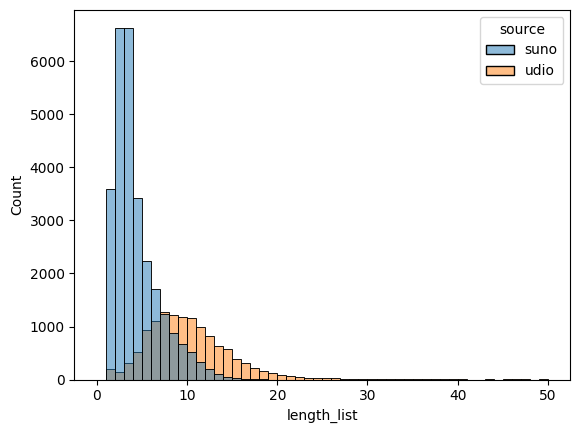

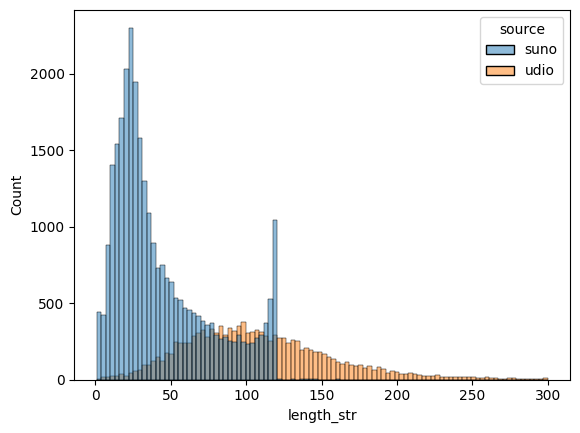

In [ ]:
sns.histplot(
    data=tags_df[tags_df['length_list'] > 0],
    x='length_list',
    hue='source',
    bins=50,
    binrange=(0, 50)
    # multiple='stack'
)
plt.show()

tags_df['length_str'] = tags_df.apply(lambda x: len(", ".join(x['tags_list'])) if isinstance(x['tags'], list) else len(x['tags']), axis=1)
sns.histplot(
    data=tags_df[tags_df['length_str'] > 0],
    x='length_str',
    hue='source',
    bins=100,
    binrange=(1, 300)
)
plt.show()

In [ ]:
tags_df[tags_df['length_list'] > 0].groupby('source')['length_list'].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
suno,2.82e+04,3.80e+00,2.54e+00,1.00e+00,2.00e+00,3.00e+00,5.00e+00,1.90e+01
udio,1.27e+04,9.83e+00,5.69e+00,1.00e+00,6.00e+00,9.00e+00,1.20e+01,1.42e+02


In [ ]:
tags_df[tags_df['length_str'] > 0].groupby('source')['length_str'].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
suno,2.91e+04,4.34e+01,3.23e+01,1.00e+00,2.00e+01,3.10e+01,6.00e+01,1.62e+02
udio,1.27e+04,1.16e+02,1.08e+02,1.00e+00,7.30e+01,1.03e+02,1.38e+02,6.41e+03


In [ ]:
print("total suno tags", suno_tags_count['count'].shape)
print("total udio tags", udio_tags_count['count'].shape)

count_combined = pd.merge(left=suno_tags_count, right=udio_tags_count, on=['tag', 'length'], how='outer', suffixes=('_suno', '_udio'))
count_combined[['count_suno', 'count_udio']] = count_combined[['count_suno', 'count_udio']].fillna(0)
count_combined['total'] = count_combined['count_suno'] + count_combined['count_udio']
print("total combined tags", count_combined['total'].shape)

print("Percentage of combined tags that appear less than 10 times")
print(f"{(count_combined[count_combined['total'] < 10].shape[0] / count_combined.shape[0] * 100):.2f}%")
print("percentage of tags that appear only once")
print(f"{(count_combined[count_combined['total'] == 1].shape[0] / count_combined.shape[0] * 100):.2f}%")
print("percentage of tags that appear less than 2 times")
print(f"{(count_combined[count_combined['total'] <= 2].shape[0] / count_combined.shape[0] * 100):.2f}%")

count_combined[count_combined['total']>=10].sort_values('total', ascending=False)

# count_combined[(count_combined['count_suno']>=10) & (count_combined['count_udio']>=10)].sort_values('total', ascending=False)

total suno tags (18695,)
total udio tags (7656,)
total combined tags (24058,)
Percentage of combined tags that appear less than 10 times
94.81%
percentage of tags that appear only once
76.02%
percentage of tags that appear less than 2 times
84.99%


,tag,count_suno,length,count_udio,total
14826,melodic,1.32e+03,7,5.08e+03,6.40e+03
18662,rock,2.02e+03,4,4.28e+03,6.30e+03
17053,pop,3.97e+03,3,2.31e+03,6.27e+03
14437,male vocalist,7.60e+01,13,4.47e+03,4.55e+03
8123,electronic,1.62e+03,10,2.57e+03,4.19e+03
...,...,...,...,...,...
4269,british+,0.00e+00,8,1.00e+01,1.00e+01
18339,remark/catchy,0.00e+00,13,1.00e+01,1.00e+01
5802,country-pop,4.00e+00,11,6.00e+00,1.00e+01
5821,cowbell,3.00e+00,7,7.00e+00,1.00e+01


In [ ]:
# count_combined[count_combined['tag'].str.startswith("male")].sort_values('total', ascending=False)

In [ ]:
count_combined['tag'] = count_combined['tag'].str.strip(',').apply(lambda x: re.sub(r'\[|\]', '', x)).apply(lambda x: re.sub(r'\s+'," ",x))
# count_combined[count_combined['tag'].str.endswith(',')]


print(count_combined.shape, count_combined.drop_duplicates(subset=['tag']).shape)
count_combined = count_combined.groupby('tag').agg(
    {
        "count_suno":"sum",
        "count_udio":"sum",
        "total":"sum",
        "length":"min"
    }
).reset_index()

print("Percentage of combined tags that appear less than 10 times")
print(f"{(count_combined[count_combined['total'] < 10].shape[0] / count_combined.shape[0] * 100):.2f}%")
print("percentage of tags that appear only once")
print(f"{(count_combined[count_combined['total'] == 1].shape[0] / count_combined.shape[0] * 100):.2f}%")
print("percentage of tags that appear less than 2 times")
print(f"{(count_combined[count_combined['total'] <= 2].shape[0] / count_combined.shape[0] * 100):.2f}%")

count_combined[count_combined['total']>=10].sort_values('total', ascending=False)


(24058, 5) (23798, 5)
Percentage of combined tags that appear less than 10 times
94.77%
percentage of tags that appear only once
75.86%
percentage of tags that appear less than 2 times
84.88%


,tag,count_suno,count_udio,total,length
14602,melodic,1.34e+03,5.09e+03,6.43e+03,7
18411,rock,2.02e+03,4.28e+03,6.30e+03,4
16824,pop,3.97e+03,2.31e+03,6.27e+03,3
14211,male vocalist,7.60e+01,4.48e+03,4.56e+03,13
7923,electronic,1.62e+03,2.58e+03,4.19e+03,10
...,...,...,...,...,...
20643,strong,9.00e+00,1.00e+00,1.00e+01,6
20652,strong bass,1.00e+01,0.00e+00,1.00e+01,11
16233,orchestral strings,8.00e+00,2.00e+00,1.00e+01,18
16382,pan flute,4.00e+00,6.00e+00,1.00e+01,9


### manual classes

In [ ]:
tags_counts = count_combined.copy().rename(columns={'tag': 'tags'})
print(tags_counts.shape)
tags_counts = tags_counts[tags_counts['total'] >= 10].dropna(subset='tags').copy() #.head(350).copy()
print(f"Number of tags: {tags_counts.shape[0]}")

(23798, 5)
Number of tags: 1245


In [ ]:
tags_counts

,tags,count_suno,count_udio,total,length
142,00s,3.00e+00,7.00e+00,1.00e+01,3
191,120 bpm,2.10e+01,2.00e+00,2.30e+01,7
198,120bpm,1.60e+01,0.00e+00,1.60e+01,6
216,130 bpm,1.20e+01,2.00e+00,1.40e+01,7
225,140 bpm,1.20e+01,1.00e+00,1.30e+01,7
...,...,...,...,...,...
23558,wonky,3.00e+00,1.30e+01,1.60e+01,5
23577,world music,6.00e+00,1.00e+01,1.60e+01,11
23581,worship,1.90e+01,5.00e+00,2.40e+01,7
23605,xylophone,1.70e+01,4.00e+00,2.10e+01,9


#### enao

In [ ]:
import re
import spacy
spc = spacy.load('en_core_web_sm')

# scrape table from every noise at once
import pandas as pd 

url = 'https://everynoise.com/everynoise1d.html'

enao = pd.read_html(url)[0].rename(columns={0:'index', 1:'icon',2:'genre'})['genre'].values.tolist()
enao += ['electronic dance music','dance-pop','adult contemporary', 'heavy metal', 'northern american music', 'regional music','hip-hop','west coast hip hop','deep bass','heavy bass','neo-psychedelia'] + ['power ballad','progressive electronic','musical theater and entertainment','contemporary christian','doo wop','epic orchestral', 'drum & bass','liquid drum and bass','prog','trip-hop','dance','acapella','dancefloor', 'lo-fi hip hop','neoclassical','alternative','[witch house]','indie','film score','song','808','orchestral','spaghetti western','ballad','16-bit', 'psychedelia','post-bop', 'chillout','symphony','symphonic','rnb','retrowave','americana','psytrance','bollywood','bubblegum','fusion','psybient','rapcore','jpop','jazzy','ballad','16-bit']
enao = [g.lower() for g in enao]

In [ ]:
def is_genre(tag):
    if tag in enao: return True
    elif tag.__contains__('music'): return True
    else:
        for t in re.split(r'[,./\s-]', tag):
            if t in enao: return True
        return False

tags_counts['is_genre'] = tags_counts['tags'].apply(is_genre)
tags_counts[tags_counts['is_genre']==True]

,tags,count_suno,count_udio,total,length,is_genre
247,16-bit,9.00e+00,2.00e+00,1.10e+01,6,True
728,8-bit,1.60e+01,8.00e+00,2.40e+01,5,True
773,808,1.80e+01,2.00e+00,2.00e+01,3,True
774,808 bass,1.20e+01,2.00e+00,1.40e+01,8,True
848,80s rock,9.00e+00,4.00e+00,1.30e+01,8,True
...,...,...,...,...,...,...
23376,witch house,7.70e+01,1.50e+01,9.20e+01,11,True
23558,wonky,3.00e+00,1.30e+01,1.60e+01,5,True
23577,world music,6.00e+00,1.00e+01,1.60e+01,11,True
23581,worship,1.90e+01,5.00e+00,2.40e+01,7,True


#### instruments

In [ ]:
instrument_list = [pd.read_html('https://www.imit.org.uk/pages/a-to-z-of-musical-instrument.html')[1][0][2:].values.tolist()]
instrument_list = [x.lower() for x in instrument_list[0]]
instrument_list += ['drums', 'percussion','synth','organ','shamishen','sitar','shakuachi','koto','ukulele','bass', 'sax','bagpipe','strings','vocoder','keyboard','brass']
instrument_list += [x+'s' for x in instrument_list]

def is_instrument(tag):
    if tag in instrument_list:
        return True
    else:
        for t in re.split(r'[,./\s-]', tag):
            if t in instrument_list: return True
        return False
    
tags_counts['is_instrument'] = tags_counts['tags'].apply(is_instrument)
tags_counts[tags_counts['is_instrument'] == True]

,tags,count_suno,count_udio,total,length,is_genre,is_instrument
774,808 bass,1.20e+01,2.00e+00,1.40e+01,8,True,True
1443,accordion,3.90e+01,6.00e+00,4.50e+01,9,True,True
1524,acoustic guitar,3.19e+02,2.05e+02,5.24e+02,15,False,True
2044,alto saxophone,0.00e+00,1.30e+01,1.30e+01,14,False,True
2880,atmospheric synths,8.00e+00,2.00e+00,1.00e+01,18,False,True
...,...,...,...,...,...,...,...
22794,viola,7.00e+00,3.00e+00,1.00e+01,5,True,True
22804,violin,4.27e+02,1.23e+02,5.50e+02,6,True,True
22843,violins,2.70e+01,4.00e+00,3.10e+01,7,False,True
22998,vocoder,1.60e+01,1.40e+01,3.00e+01,7,False,True


#### spacy

In [ ]:
def is_adj(tag):
    # use spacy to detect if tag is an adjective or NER
    doc = spc(tag)
    # print([(token.text, token.pos_) for token in doc])
    if len(doc) == 0:
        return False
    elif len(doc) > 1:
        return ", ".join([t.pos_ for t in doc])
    else:
        return doc[0].pos_
    
tags_counts['POS'] = tags_counts['tags'].apply(is_adj)
# tags_counts[tags_counts['POS'].notna()].head(50)

#### other regex

In [ ]:
tags_counts['is_voice'] = tags_counts['tags'].apply(lambda x: bool(sum([str.__contains__(x,y) for y in ['voice', 'vocal','singer','falsetto','soprano','tenor','baritone','alto','choir']])))
tags_counts['is_bpm'] = tags_counts['tags'].apply(lambda x: bool(re.fullmatch(r'\d{2,3}[-\s]?bpm', x)))
tags_counts['is_year'] = tags_counts['tags'].apply(lambda x: bool(re.fullmatch(r'\d{2,4}\'?s?', x)))
tags_counts['is_key'] = tags_counts['tags'].apply(lambda x: bool(re.fullmatch(r'[a-g]?#?\s?(major|minor)(\s?key)?', x)))
# tags_counts['is_tempo'] = tags_counts['tags'].apply(lambda x: x.__contains__('tempo'))

#### struct

In [ ]:
struct_keywords = ['verse','chorus','bridge','intro','outro','hook','pre-chorus','post-chorus','interlude','solo','break','drop','refrain','coda','fade','ending','beginning','outro','intro','outro','prelude','melody','melodies','riff','riffs', 'chords', 'power chords', 'time signature', 'slow', 'fast', 'beat', 'dynamic range','uptempo','mid-tempo']

def is_structure(tag):
    # for t in re.split(r'[\s]', tag):
        # for kw in struct_keywords:
            # if t.__contains__(kw): return True
    for kw in struct_keywords:
        if kw in tag: return True
    return False

tags_counts['is_structure'] = tags_counts['tags'].apply(is_structure)

# tags_counts[tags_counts['is_structure']==True]

#### test

In [ ]:
# show which tags remain uncategorized
tags_counts[
    (tags_counts['POS'] != False)
    & (tags_counts['is_genre'] == False) 
    & (tags_counts['is_instrument'] == False)
    & (tags_counts['is_voice'] == False)
    & (tags_counts['is_bpm'] == False) & (tags_counts['is_year'] == False) & (tags_counts['is_key'] == False)
    & (tags_counts['is_structure'] == False)
    # & (tags_counts['is_tempo'] == False)
    ]

,tags,count_suno,count_udio,total,length,is_genre,is_instrument,POS,is_voice,is_bpm,is_year,is_key,is_structure
1465,acid,1.20e+01,0.00e+00,1.20e+01,4,False,False,NOUN,False,False,False,False,False
1489,acoustic,1.38e+03,3.02e+02,1.68e+03,8,False,False,ADJ,False,False,False,False,False
1611,action,1.10e+01,5.00e+00,1.60e+01,6,False,False,NOUN,False,False,False,False,False
1676,adventure,1.20e+01,1.20e+01,2.40e+01,9,False,False,NOUN,False,False,False,False,False
1775,aggressive,5.20e+02,5.53e+02,1.07e+03,10,False,False,ADJ,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23195,weird,9.00e+00,7.00e+00,1.60e+01,5,False,False,ADJ,False,False,False,False,False
23203,well produced,9.00e+00,1.00e+00,1.00e+01,13,False,False,"ADV, VERB",False,False,False,False,False
23226,western,3.80e+01,1.00e+01,4.80e+01,7,False,False,ADJ,False,False,False,False,False
23262,whimsical,2.00e+01,5.00e+00,2.50e+01,9,False,False,ADJ,False,False,False,False,False


#### apply labels

In [ ]:
def get_labels(row):
    if row['is_structure'] == True: return 'STRUCTURE'
    elif row['is_instrument'] == True: return 'INSTRUMENT'
    elif row['is_genre'] == True: return 'GENRE/STYLE'
    elif row['is_voice'] == True: return 'VOICE'
    elif row['is_bpm'] == True: return 'BPM'
    elif row['is_year'] == True: return 'YEAR'
    elif row['is_key'] == True: return 'KEY'
    # elif row['is_tempo'] == True: return 'TEMPO'
    # if all is none and just pos then 
    # elif row['POS'] != False: return 'QUALIFIER'
    elif ("ADJ" in row['POS'] or "VERB" in row['POS']): return 'QUALIFIER'
    # the remainder is other
    else: return 'OTHER'

tags_counts['LABEL'] = tags_counts.apply(get_labels, axis=1)

# put label as column 2
cols = tags_counts.columns.tolist()
cols.insert(1, cols.pop(cols.index('LABEL')))
tags_counts = tags_counts[cols]
tags_counts.sort_values("LABEL").to_csv('NEW_tags_counts_manual_cat_v2.csv')

In [ ]:
tags_counts[tags_counts['LABEL'] == 'OTHER']

,tags,LABEL,count_suno,count_udio,total,length,is_genre,is_instrument,POS,is_voice,is_bpm,is_year,is_key,is_structure
1465,acid,OTHER,1.20e+01,0.00e+00,1.20e+01,4,False,False,NOUN,False,False,False,False,False
1611,action,OTHER,1.10e+01,5.00e+00,1.60e+01,6,False,False,NOUN,False,False,False,False,False
1676,adventure,OTHER,1.20e+01,1.20e+01,2.40e+01,9,False,False,NOUN,False,False,False,False,False
1878,alcohol,OTHER,0.00e+00,2.00e+01,2.00e+01,7,False,False,PROPN,False,False,False,False,False
1898,alienation,OTHER,1.00e+00,3.70e+01,3.80e+01,10,False,False,NOUN,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22782,vinyl,OTHER,1.10e+01,1.00e+00,1.20e+01,5,False,False,NOUN,False,False,False,False,False
23051,vulgar,OTHER,0.00e+00,7.60e+01,7.60e+01,6,False,False,NOUN,False,False,False,False,False
23077,waltz,OTHER,9.00e+00,5.00e+00,1.40e+01,5,False,False,NOUN,False,False,False,False,False
23084,war,OTHER,1.00e+01,3.20e+01,4.20e+01,3,False,False,NOUN,False,False,False,False,False


In [ ]:
tags_counts['LABEL'].value_counts()

LABEL
GENRE/STYLE    650
QUALIFIER      314
INSTRUMENT     107
STRUCTURE       74
VOICE           51
YEAR            22
OTHER           12
KEY             10
BPM              6
Name: count, dtype: int64

In [ ]:
# # extend pandas column width
# pd.set_option('display.max_colwidth', 50)

# tags_df[tags_df['tags_list'].apply(lambda x: "aor" in x)]

##### manual edits

In [ ]:
# KEY is ok
# BPM is ok
# YEARS is ok
# VOICE is ok
# STRUCTURE
tags_counts.at[4131, 'LABEL'] = 'QUALIFIER' # breakup
tags_counts.at[4887, 'LABEL'] = 'KEY' # chorus in minor
tags_counts.at[12682, 'LABEL'] = 'QUALIFIER' # introspective
tags_counts.at[8797, 'LABEL'] = 'GENRE/STYLE' # eurobeat
tags_counts.at[19581, 'LABEL'] = 'GENRE/STYLE' # slow rock
tags_counts.at[14863, 'LABEL'] = 'GENRE/STYLE' # merseybeat
tags_counts.at[19631, 'LABEL'] = 'GENRE/STYLE' # slowcore
tags_counts.at[3953, 'LABEL'] = 'GENRE/STYLE' # breakcore

# OTHER
corrections = [
    (23077,"waltz","GENRE/STYLE"),
    (11793,"hiphop","GENRE/STYLE"),
    (23084,"war","QUALIFIER"),
    (17264,"powerfull","QUALIFIER"),
    (2645,"aor","GENRE/STYLE"),
    (19331,"sinister","QUALIFIER"),
    (6892,"dj","QUALIFIER"),
    (6912,"dnb","GENRE/STYLE"),
    (6929,"dolby atmos","QUALIFIER"),
    (4030,"british","QUALIFIER"),
    (17121,"power","QUALIFIER"),
    (22311,"underground","QUALIFIER"),
    (7336,"drumstep","GENRE/STYLE"),
    (4263,"calm","QUALIFIER"),
    (10709,"groovy","QUALIFIER"),
    (2548,"angsty","QUALIFIER"),
    (16531,"pessimistic","QUALIFIER"),
    (19996,"sombre","QUALIFIER"),
    (12017,"hymn","GENRE/STYLE"),
    (6804,"disney","QUALIFIER"),
    (6819,"dissonant","QUALIFIER"),
    (16707,"piz","QUALIFIER"),
    (8177,"emotion","QUALIFIER"),
    (7388,"duet","STRUCTURE"),
    (9781,"forest","QUALIFIER"),
    (13499,"lgbt","QUALIFIER"),
    (11894,"horror","QUALIFIER"),
    (11867,"hope","QUALIFIER"),
    (10697,"groove","QUALIFIER"),
    (8822,"evil","QUALIFIER"),
    (6865,"distortion","QUALIFIER"),
    (3811,"bouncy","QUALIFIER"),
    (17430,"protest","QUALIFIER"),
    (6958,"doom","QUALIFIER"),
    (18675,"rythm","QUALIFIER"),
    (1611,"action","QUALIFIER"),
    (18588,"romanticism","GENRE/STYLE"),
    (18097,"remix","QUALIFIER"),
    (18117,"repetitive","QUALIFIER"),
    (18124,"resilience","QUALIFIER"),
    (18145,"retro","QUALIFIER"),
    (1676,"adventure","QUALIFIER"),
    (13697,"lofi","GENRE/STYLE"),
    (13816,"love","QUALIFIER"),
    (11047,"hard","QUALIFIER"),
    (3075,"ballads","GENRE/STYLE"),
    (3087,"band","QUALIFIER"),
    (3094,"banger","QUALIFIER"),
    (13784,"loud","QUALIFIER"),
    (11004,"handclaps","STRUCTURE"),
    (18226,"rhythm","STRUCTURE"),
    (19099,"serene","QUALIFIER"),
    (2940,"autumn","QUALIFIER"),
    (2936,"autotune","VOICE"),
    (16402,"party","QUALIFIER"),
    (23362,"winter","QUALIFIER"),
    (19072,"self-hatred","QUALIFIER"),
    (14124,"male lead","VOICE"), 
    (2815,"atmospheric","QUALIFIER"),
    (14040,"male","QUALIFIER"),
    (18958,"score","QUALIFIER"),
    (17907,"raw","QUALIFIER"),
    (18952,"science fiction","QUALIFIER"), 
    (9618,"fire","QUALIFIER"),
    (17738,"rage","QUALIFIER"),
    (3458,"bhm","GENRE/STYLE"),
    (11214,"harmony","STRUCTURE"),
    (11196,"harmonies","STRUCTURE"),
    (11185,"harmonica","INSTRUMENT"),
    (8319,"emotive","QUALIFIER"),
    (18949,"sci-fi","QUALIFIER"),
    (9898,"fun","QUALIFIER"),
    (13369,"latin","QUALIFIER"),
    (22728,"video game","QUALIFIER"), 
    (6363,"death","GENRE/STYLE"),
    (20825,"sultry","QUALIFIER"),
    (20822,"suite","STRUCTURE"),
    (15528,"mythology","QUALIFIER"),
    (6395,"deep","QUALIFIER"),
    (15568,"nature","QUALIFIER"),
    (20724,"studio quality","QUALIFIER"), 
    (22782,"vinyl","QUALIFIER"),
    (5253,"club","QUALIFIER"),
    (22759,"vintage","QUALIFIER"),
    (10142,"gangsta","GENRE/STYLE"),
    (4663,"children","QUALIFIER"),
    (7734,"electric","QUALIFIER"),
    (10154,"garage","GENRE/STYLE"),
    (20452,"standards","QUALIFIER"),
    (5026,"classic","GENRE/STYLE"),
    (13495,"lethargic","QUALIFIER"),
    (5399,"concept album","QUALIFIER"),
    (15843,"noisy","QUALIFIER"),
    (20843,"summer","QUALIFIER"),
    (15338,"motivational","QUALIFIER"),
    (1878,"alcohol","QUALIFIER"),
    (1898,"alienation","QUALIFIER"),
    (10021,"future","QUALIFIER"),
    (8501,"epic","QUALIFIER"),
    (23051,"vulgar","QUALIFIER"),
    (13218,"kids","QUALIFIER"),
    (5632,"cowboy","QUALIFIER"),
    (8778,"euphoric","QUALIFIER"),
    (5705,"creepy","QUALIFIER"),
    (9246,"female","QUALIFIER"),
    (5717,"crescendo","STRUCTURE"),
    (21927,"trailer","QUALIFIER"),
    (15063,"minimalist","QUALIFIER"),
    (15100,"misanthropic","QUALIFIER"),
    (13026,"jingle","QUALIFIER"),
    (12855,"japanese","QUALIFIER"),
    (12826,"jamaican","QUALIFIER"),
    (20903,"surf","GENRE/STYLE"),
    (4958,"cinematic","QUALIFIER"),
    (4576,"chant","VOICE"),
    (7571,"echoes","QUALIFIER"),
    (20325,"sparse","QUALIFIER"),
    (4903,"christian","QUALIFIER"),
    (20268,"space","QUALIFIER"),
    (10504,"goth","GENRE/STYLE"),
    (10394,"glitchy","QUALIFIER"),
    (15992,"occult","QUALIFIER"),
    (10522,"gothic","GENRE/STYLE"),
    (12176,"improvisation","STRUCTURE"),
    (4924,"christmas","QUALIFIER"),
    (8454,"english","QUALIFIER"),
    (4691,"chill","QUALIFIER"),
    (1465,"acid","GENRE/STYLE"),
    (12143,"idm","GENRE/STYLE"),
    (15884,"nostalgia","QUALIFIER"),
    (5731,"crisp","QUALIFIER"),
    (11572,"hi-fi","QUALIFIER"),
    (11974,"humor","QUALIFIER"),
    (12617,"interview","QUALIFIER"),
    (12710,"irish","GENRE/STYLE"),
    (14362,"masterpiece","QUALIFIER"),
    (14459,"medium tempo","STRUCTURE"),
    (15744,"night","QUALIFIER"),
    (18089,"remark/catchy","QUALIFIER"),
    (18818,"sadness","QUALIFIER"),
    (18859,"samples","QUALIFIER"),
    (19947,"solemn","QUALIFIER"),
]

for idx,tag,label in corrections:
    # print(idx,tag,label)
    tags_counts.at[idx,"LABEL"] = label

# INSTRUMENT
tags_counts.at[11453, 'LABEL'] = 'STRUCTURE' # heavy guitar riffs
tags_counts.at[10867, 'LABEL'] = 'STRUCTURE' # guitar riffs
tags_counts.at[10870, 'LABEL'] = 'STRUCTURE' # guitar riff
tags_counts.at[10878, 'LABEL'] = 'STRUCTURE' # guitar solo
tags_counts.at[10845, 'LABEL'] = 'STRUCTURE' # guitar intro

# QUALIFIER
tags_counts.at[12489, 'LABEL'] = 'STRUCTURE' # instrumental intro
tags_counts.at[12503, 'LABEL'] = 'STRUCTURE' # instrumental
tags_counts.at[6344, 'LABEL'] = 'GENRE/STYLE' # darkwave
tags_counts.at[13279, 'LABEL'] = 'GENRE/STYLE' # kpop
tags_counts.at[11512, 'LABEL'] = 'STRUCTURE' # heavy riffs
tags_counts.at[3326, 'LABEL'] = 'STRUCTURE' # beat drop
tags_counts.at[7244, 'LABEL'] = 'INSTRUMENT' # drum
tags_counts.at[15257, 'LABEL'] = 'GENRE/STYLE' # mongolian throat singing


In [ ]:
# tags_counts[tags_counts['LABEL'] == 'OTHER'][['tags']]

In [ ]:
# print(tags_counts.shape)
# tags_counts["LABEL"].value_counts()

In [ ]:
tags_counts.sort_values("LABEL").to_csv('NEW_tags_counts_manual_cat_v2.csv')

### complexity of a tag string?

['GENRE/STYLE', 'QUALIFIER', 'INSTRUMENT', 'STRUCTURE', 'VOICE', 'YEAR', 'KEY', 'BPM', 'UNDEFINED']


  0%|          | 0/28222 [00:00<?, ?it/s]

,Expected Number of Tags
GENRE/STYLE,1.15e+00
QUALIFIER,8.38e-01
INSTRUMENT,2.54e-01
STRUCTURE,1.34e-01
VOICE,1.27e-01
YEAR,2.98e-02
KEY,3.65e-03
BPM,1.63e-03
UNDEFINED,1.26e+00


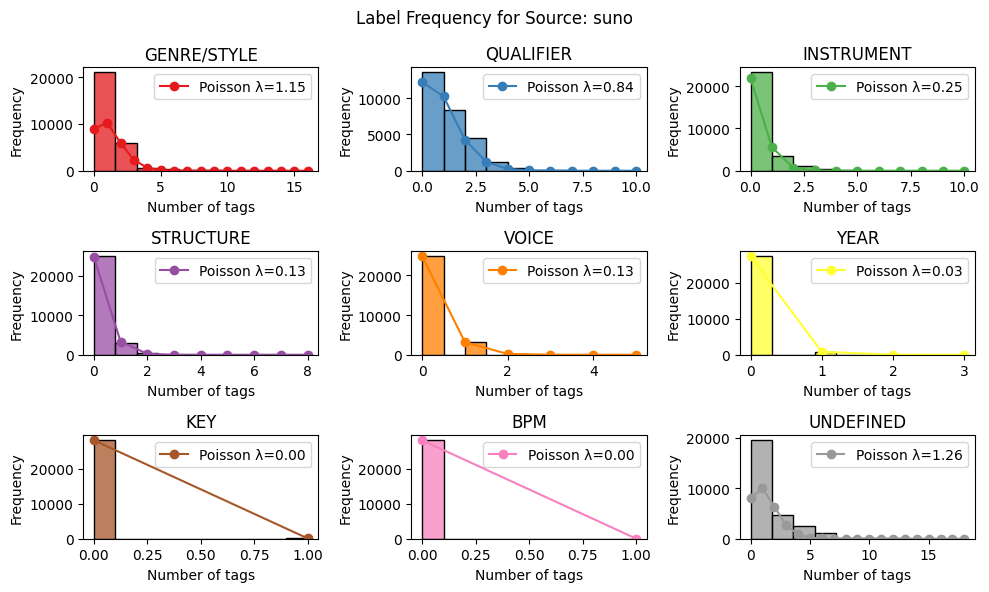

In [ ]:
# import math
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from tqdm.auto import tqdm
from IPython.display import display

# tags_counts = pd.read_csv('NEW_tags_counts_manual_cat_v2.csv')

labels = tags_counts['LABEL'].value_counts().index.tolist() + ["UNDEFINED"]
print(labels)

def label_freq(source):
    sample = tags_df[(tags_df['length_list'] > 0) & (tags_df['source'] == source)]#.sample(100)
    label_freq = {l: [] for l in labels}
    
    def count_label_occurence(tags_list, labels, tags_counts):
        freqs = {
            l:0 for l in labels
        }
        for tag in tags_list:
            # if tag in tags_counts l = LABEL else l="UNDEFINED"
            if tag in tags_counts['tags'].values:
                l = tags_counts[tags_counts['tags'] == tag]['LABEL'].values[0]
            else:
                l = "UNDEFINED"
            # print(l)
            freqs[l] += 1

        # update label_freq dict
        for l in labels:
            label_freq[l].append(freqs[l])
    
    # compute freqs
    sample.progress_apply(
        lambda row: count_label_occurence(row["tags_list"], labels, tags_counts), axis=1
    )

    # print as table
    expected_tags_df = pd.DataFrame.from_dict(
        {l: np.mean(label_freq[l]) for l in labels}, 
        orient="index", columns=["Expected Number of Tags"]
    )
    display(expected_tags_df)

    # for each label, plot histogram and the fitted possion distribution, indicate lambda in the legend
    fig, axs = plt.subplots(3, 3, figsize=(10, 6))
    for i, label in enumerate(labels):
            ax = axs[i // 3, i % 3]
            data = label_freq[label]
            # histogram bins (centered on integers)
            max_k = int(max(data))
            bins = 10#np.arange(0, max_k + 2) - 0.5
            color = sns.color_palette("Set1", 9)[i]
            sns.histplot(
                 data=data,
                 bins=bins,
                 ax=ax,
                 color=color
            )

            # fit Poisson lambda and compute PMF scaled to counts
            lam = np.mean(data)
            ks = np.arange(0, max_k + 1)
            pmf = np.exp(-lam) * (lam ** ks) / np.array([math.factorial(k) for k in ks])
            ax.plot(ks, pmf * len(data), '-o', label=f'Poisson λ={lam:.2f}', color=color)

            ax.set_title(label)
            ax.set_xlabel('Number of tags')
            ax.set_ylabel('Frequency')
            ax.legend()
    plt.suptitle(f"Label Frequency for Source: {source}")
    plt.tight_layout()
    plt.show()
    return label_freq



suno_label_freq = label_freq("suno")

  0%|          | 0/12732 [00:00<?, ?it/s]

,Expected Number of Tags
GENRE/STYLE,3.90e+00
QUALIFIER,3.56e+00
INSTRUMENT,2.58e-01
STRUCTURE,2.96e-01
VOICE,6.08e-01
YEAR,5.39e-02
KEY,3.53e-03
BPM,3.93e-04
UNDEFINED,1.15e+00


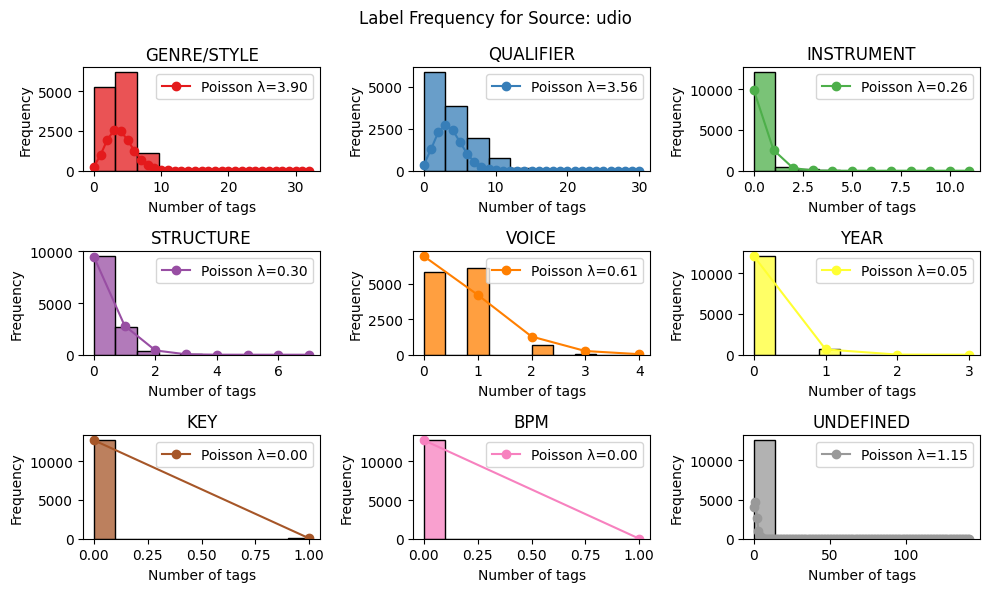

In [ ]:
udio_label_freq = label_freq("udio")

In [ ]:
# table for paper
# create a dataframe with a row for each label
# one level of column: suno and udio
# second level: mean, std, min, 25, 50, 75, quantiles, max
summary_stats = {}
for label in labels:
    suno_data = suno_label_freq[label]
    udio_data = udio_label_freq[label]
    summary_stats[label] = {
        'suno_mean': np.mean(suno_data),
        # 'suno_std': np.std(suno_data),
        # 'suno_min': np.min(suno_data),
        'suno_25%': np.percentile(suno_data, 25),
        'suno_50%': np.percentile(suno_data, 50),
        'suno_75%': np.percentile(suno_data, 75),
        'suno_max': np.max(suno_data),
        'udio_mean': np.mean(udio_data),
        'udio_std': np.std(udio_data),
        'udio_min': np.min(udio_data),
        'udio_25%': np.percentile(udio_data, 25),
        'udio_50%': np.percentile(udio_data, 50),
        'udio_75%': np.percentile(udio_data, 75),
        'udio_max': np.max(udio_data),
    }

summary_df = pd.DataFrame.from_dict(summary_stats, orient='index')
summary_df

,suno_mean,suno_25%,suno_50%,suno_75%,suno_max,udio_mean,udio_std,udio_min,udio_25%,udio_50%,udio_75%,udio_max
GENRE/STYLE,1.15e+00,0.00e+00,1.00e+00,2.00e+00,16,3.90e+00,2.22e+00,0,3.00e+00,4.00e+00,5.00e+00,32
QUALIFIER,8.38e-01,0.00e+00,1.00e+00,1.00e+00,10,3.56e+00,3.40e+00,0,1.00e+00,3.00e+00,5.00e+00,30
INSTRUMENT,2.54e-01,0.00e+00,0.00e+00,0.00e+00,10,2.58e-01,7.23e-01,0,0.00e+00,0.00e+00,0.00e+00,11
STRUCTURE,1.34e-01,0.00e+00,0.00e+00,0.00e+00,8,2.96e-01,5.60e-01,0,0.00e+00,0.00e+00,1.00e+00,7
VOICE,1.27e-01,0.00e+00,0.00e+00,0.00e+00,5,6.08e-01,6.19e-01,0,0.00e+00,1.00e+00,1.00e+00,4
YEAR,2.98e-02,0.00e+00,0.00e+00,0.00e+00,3,5.39e-02,2.33e-01,0,0.00e+00,0.00e+00,0.00e+00,3
KEY,3.65e-03,0.00e+00,0.00e+00,0.00e+00,1,3.53e-03,5.93e-02,0,0.00e+00,0.00e+00,0.00e+00,1
BPM,1.63e-03,0.00e+00,0.00e+00,0.00e+00,1,3.93e-04,1.98e-02,0,0.00e+00,0.00e+00,0.00e+00,1
UNDEFINED,1.26e+00,0.00e+00,0.00e+00,2.00e+00,18,1.15e+00,4.14e+00,0,0.00e+00,0.00e+00,1.00e+00,142


In [ ]:
# for each label, make a table with the mean number of tags for suno and udio, the percentage of songs with at least one tag of that label, and the probability of having at least one tag according to the poisson formula
poisson_table = []
for label in labels:
    suno_data = suno_label_freq[label]
    udio_data = udio_label_freq[label]
    suno_lambda = np.mean(suno_data)
    udio_lambda = np.mean(udio_data)
    suno_prob = 1 - np.exp(-suno_lambda)
    udio_prob = 1 - np.exp(-udio_lambda)
    suno_pct = np.sum(np.array(suno_data) > 0) / len(suno_data) * 100
    udio_pct = np.sum(np.array(udio_data) > 0) / len(udio_data) * 100
    poisson_table.append({
        'label': label,
        'suno_mean_tags': suno_lambda,
        'udio_mean_tags': udio_lambda,
        'suno_pct_songs_with_tag': suno_pct,
        'udio_pct_songs_with_tag': udio_pct,
        'suno_poisson_prob': suno_prob,
        'udio_poisson_prob': udio_prob,
    })
poisson_df = pd.DataFrame(poisson_table)
# use scientific notation for mean tags and poisson prob
pd.set_option('display.float_format', '{:.2e}'.format)
poisson_df

,label,suno_mean_tags,udio_mean_tags,suno_pct_songs_with_tag,udio_pct_songs_with_tag,suno_poisson_prob,udio_poisson_prob
0,GENRE/STYLE,1.15e+00,3.90e+00,7.11e+01,9.21e+01,6.84e-01,9.80e-01
1,QUALIFIER,8.38e-01,3.56e+00,5.19e+01,7.98e+01,5.67e-01,9.72e-01
2,INSTRUMENT,2.54e-01,2.58e-01,1.75e+01,1.66e+01,2.24e-01,2.28e-01
3,STRUCTURE,1.34e-01,2.96e-01,1.19e+01,2.51e+01,1.26e-01,2.56e-01
4,VOICE,1.27e-01,6.08e-01,1.20e+01,5.42e+01,1.19e-01,4.55e-01
5,YEAR,2.98e-02,5.39e-02,2.92e+00,5.23e+00,2.93e-02,5.25e-02
6,KEY,3.65e-03,3.53e-03,3.65e-01,3.53e-01,3.64e-03,3.53e-03
7,BPM,1.63e-03,3.93e-04,1.63e-01,3.93e-02,1.63e-03,3.93e-04
8,UNDEFINED,1.26e+00,1.15e+00,3.95e+01,3.10e+01,7.17e-01,6.84e-01


### wordclouds

In [ ]:
count_combined

,tag,count_suno,count_udio,total,length
0,,0.00e+00,1.00e+00,1.00e+00,2
1,!no instruments,1.00e+00,0.00e+00,1.00e+00,15
2,""" ^'loud city barking in the stands",0.00e+00,1.00e+00,1.00e+00,36
3,""" mature male voices",1.00e+00,0.00e+00,1.00e+00,20
4,""" should be a fun and upbeat pop tune with ele...",1.00e+00,0.00e+00,1.00e+00,71
...,...,...,...,...,...
23793,🎵 tone: mysterious,1.00e+00,0.00e+00,1.00e+00,18
23794,🎵 tone: playful,1.00e+00,0.00e+00,1.00e+00,15
23795,💃🕺🕺💃,1.00e+00,0.00e+00,1.00e+00,4
23796,💦 soul felt,1.00e+00,0.00e+00,1.00e+00,11


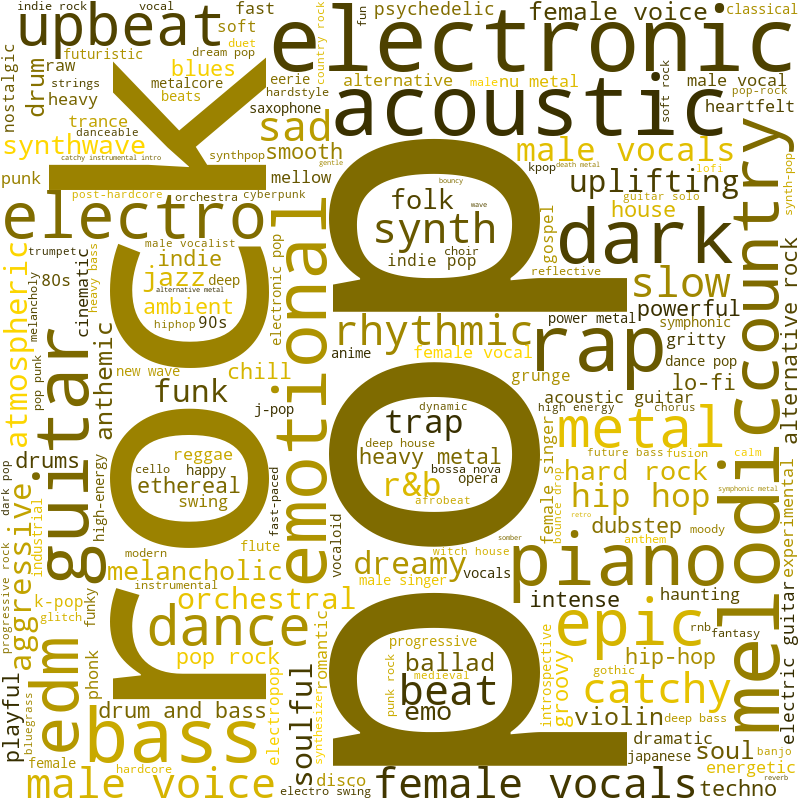

In [ ]:
import wordcloud

wc = wordcloud.WordCloud(width=800, height=800, max_words=200, background_color='white')

wc.generate_from_frequencies({x[0]:x[1] for x in count_combined[['tag','count_suno']].values})
wc.recolor(color_func=wordcloud.get_single_color_func('gold'))
wc.to_file('./figs/NEW_suno_tags_wc.png')
wc.to_image()

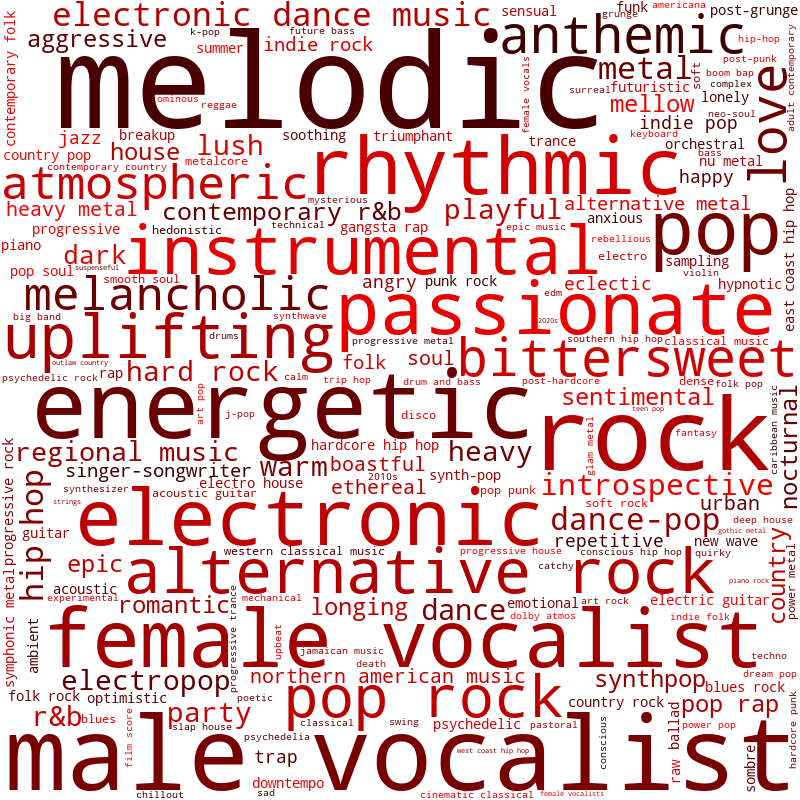

In [ ]:
wc.generate_from_frequencies({x[0]:x[1] for x in count_combined[['tag','count_udio']].values})
wc.recolor(color_func=wordcloud.get_single_color_func('red'))
wc.to_file('./figs/NEW_udio_tags_wc.png')
wc.to_image()

### embeddings and scatter

In [ ]:
import pandas as pd
import numpy as np

# tags_counts = pd.read_pickle('./tags_counts.pkl')
# X = pd.read_pickle('tags_counts_top250.pkl')
X = pd.read_csv('NEW_tags_counts_manual_cat_v2.csv').reset_index(drop=True).sort_values('total', ascending=False)
print(X.shape)
X['tags'] = X.tags.astype(str)
# rename column LABEL to label_name
X = X.rename(columns={'LABEL':'label_name'})

# transform X.label into a unique number
X['label_id'] = X['label_name'].astype('category').cat.codes
# print(X['label_id'].value_counts())

# X.at[175, 'LABEL'] = 'QUALIFIER'
# X[X['tags'] == 'ai']
# X.at[907, 'LABEL'] = 'QUALIFIER'
    
X[['label_name','label_id']].value_counts()

(1246, 15)


label_name   label_id
GENRE/STYLE  1           657
QUALIFIER    4           323
INSTRUMENT   2           108
STRUCTURE    5            69
VOICE        6            51
YEAR         7            22
KEY          3            10
BPM          0             6
Name: count, dtype: int64

In [ ]:
# assert that there are no None values in X['tags']
assert X['tags'].isnull().sum() == 0
# assert that all tags are at least 1 char long
assert (X['tags'].str.len() > 0).all()

In [ ]:
# !pip uninstall -y transformer-engine
# !pip install torch==2.2.0
# !pip install transformers==4.42.4
# !pip install flash-attn==2.2.0
# !pip install sentence-transformers==2.7.0

In [ ]:

from transformers import BitsAndBytesConfig, AutoModel
from torch import float16
from torch.nn import functional as F
import os

os.environ['TOKENIZERS_PARALLELISM'] = "false"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=float16
    )

# load model with tokenizer
model = AutoModel.from_pretrained(
    'nvidia/NV-Embed-v2', 
    trust_remote_code=True,
    quantization_config=quantization_config,
    )

# df['len_tok'] = df['lyrics'].apply(lambda x: len(model.tokenizer.encode(x)))
# df = df[df['len_tok'] <= 10_000]

`low_cpu_mem_usage` was None, now set to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# emb = model.encode(lyrics, instruction="", max_length=max([len(l) for l in lyrics]))
emb = model._do_encode(
    X['tags'].values[:], 
    batch_size=32, 
    instruction="", 
    max_length=500, 
    num_workers=32, 
    return_numpy=False
    )
emb = F.normalize(emb, p=2, dim=1).to('cpu').numpy()
X['nv_emb'] = emb.tolist()

encoding:   0%|          | 0/39 [00:02<?, ?it/s]

/root/.cache/huggingface/modules/transformers_modules/nvidia/NV-Embed-v2/3fa59658547db50a1e8e3346cf057fd0c77ed6ef/modeling_nvembed.py:347: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

/usr/lib/python3.12/contextlib.py:105: FutureWarning:

`torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.



#### umap to scatterplot

In [ ]:
# X.loc[X['tags'] == 'ccm', 'label_name'] = "GENRE/STYLE"
X["total"] = X["total"].fillna(0)

In [ ]:
# plot using umap
import umap
import umap.umap_ as umap
import plotly.express as px

reducer = umap.UMAP(
        n_neighbors=10,
        min_dist=0.05,
        n_components=5,
        metric="cosine",
        n_jobs=32,
    )

X_embedded = reducer.fit_transform(emb, y=X['label_id'])
print(X_embedded.shape)

for component in range(X_embedded.shape[1]):
    X[f'umap_d{component}'] = X_embedded[:,component]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



(1246, 5)


In [ ]:
from sklearn.cluster import HDBSCAN
from tqdm import tqdm 

# X = pd.read_pickle('tags_counts_nvemb_manual.pkl')

X_embedded = X[['umap_d0','umap_d1','umap_d2','umap_d3','umap_d4']].values

hdb = HDBSCAN(
    # min_samples=5,
    min_cluster_size=5,
    max_cluster_size=25,
    # max_cluster_size=100,
    cluster_selection_epsilon=0.15,
    n_jobs=32,
)

X['hdb_label'] = hdb.fit_predict(X_embedded)
X['hdb_label'] = X['hdb_label'].astype(str)
# X['hdb_label'].value_counts().reset_index()
# cluster_names = cluster_bow(X,'hdb_label',top_k=3, verbose=False)

cluster_names = {}
for label in X['hdb_label'].unique():
    if label == '-1':
        cluster_names[label] = 'OUTLIERS'
        continue
    top3 = X[X['hdb_label'] == label].sort_values('total', ascending=False).head(3)['tags'].values
    words = '_'.join(top3)
    cluster_names[label] = words

X['hdb_names'] = X['hdb_label'].apply(lambda x: cluster_names[x])
X[['hdb_names', 'hdb_label']].value_counts().reset_index()

,hdb_names,hdb_label,count
0,OUTLIERS,-1,269
1,female vocalist_female vocals_female voice,16,35
2,instrumental_duet_harmonies,9,32
3,mellow_warm_soft,39,25
4,piano_violin_cello,19,25
...,...,...,...
76,gothic_gothic metal_gothic rock,42,5
77,electronic_mechanical_electric,6,5
78,experimental_experimental rock_experimental hi...,46,5
79,sensual_hedonistic_sexy,44,5


In [ ]:
import umap.umap_ as umap

emb = X['nv_emb'].values.tolist()

reducer = umap.UMAP(
        n_neighbors=50,
        min_dist=0.5,
        n_components=2,
        metric="cosine",
        n_jobs=32,
    )

umap2d = reducer.fit_transform(emb, y=X['hdb_label'])
X['umap_x'] = umap2d[:,0]
X['umap_y'] = umap2d[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
X.to_json('./dash_server/tags_counts_nvemb_manual.json', orient='records')

#### plot

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

X = pd.read_json('./dash_server/tags_counts_nvemb_manual.json', orient='records')
 
# map label_id to colors
colors = px.colors.qualitative.Plotly_r
label_color_map = {label:colors[i] for i,label in enumerate(X['label_name'].unique())}

# just for paper, if hdb_name == 'OUTLIERS' then label_name == 'OUTLIERS'
# X.loc[X['hdb_names'] == 'OUTLIERS', 'label_name'] = 'OUTLIERS'
# change QUALIFIER into QUALIFIER/MOOD
# X.loc[X['label_name'] == 'QUALIFIER', 'label_name'] = 'QUALIFIER/MOOD'

fig = px.scatter(
    X, 
    x="umap_x", 
    y="umap_y", 
    size = round(5 * np.power(X['total'], 0.5)),
    hover_data=["tags","hdb_label","hdb_names","total","label_name",'label_id'], 
    color="label_name",
    color_discrete_map=label_color_map,
    # title="HDBSCAN clusters of tags embeddings (NV-Embedv2)",
    # render_mode='webgl',
    # category_orders = {"label_name": X[['label_name']].value_counts().reset_index()['label_name'].values.tolist()}
    )
fig.update_traces(marker=dict(opacity=0.5))


fig.for_each_trace(
    lambda t: t.update(marker={
        'opacity':[0.15 if x[1] == -1 else 0.5 for x in t['customdata']],
        'color' : ['#ddd' if x[2] == 'OUTLIERS' else t['marker']['color'] for x in t['customdata']],
        # # OUTLIERS show have black outline
        'line' : {'color' : ['#666' if x[1] == -1 else 'white' for x in t['customdata']]},
        'color':["#fff" if x[1] == -1 else label_color_map[x[4]] for x in t['customdata']],
        # 'line' : [print(x) for x in t['customdata']],
        'size' : 5 * t['marker']['size']
                   }))


for label in X['hdb_label'].unique():
    if label == '-1':
        continue
    top_tags = X[X['hdb_label'] == label].sort_values('total', ascending=False).head(1)
    centroid = X[X['hdb_label'] == label][['umap_x','umap_y']].median()
    # if label == '40': 
    #     # print('asdas')
    #     centroid += [-1.0, -5.0]
        
    for t in top_tags.iterrows():
        fig.add_trace(go.Scattergl(
            # x=[t[1]['umap_x']],y=[t[1]['umap_y']],
            x=[centroid['umap_x']], y=[centroid['umap_y']],
            mode='text',
            marker=dict(size=8, color='black'),
            text=t[1]['tags'],
            # font=dict(size=18),
            textposition="middle center",
            showlegend=False,
            # zorder=999
        ))

# # make text bigger in each trace
# fig.update_traces(textfont_size=16)

fig.update_layout(
    width=1600, 
    height=900,
    margin=dict(l=10, r=10, t=10, b=10),
    font=dict(size=18),
    # legend=dict(
    #     yanchor="top",
    #     xanchor="right",
    #     y=0.01,
    #     x=0.9,
    #     title='',
    #     bgcolor='rgba(255,255,255,0.5)',
    #     bordercolor='rgba(255,255,255,0.5)',
    #     borderwidth=1,
    # )
)
fig.update_xaxes(visible=False) #, range = ([2.0, 15.0]))
fig.update_yaxes(visible=False) #, range = ([2.0, 13.5]))

# # # change background color to white
fig.update_layout(plot_bgcolor='white')

fig.show()
fig.write_image('./paper/NEW_tags_bgw_2x1.pdf')

In [ ]:
X.to_pickle("NEW_tags_clusters.pkl")

# Real artists in prompts/lyrics

## replaced artist names in udio tags

In [ ]:
import pandas as pd
from tqdm import tqdm

udio_df = pd.read_pickle("udio_metadata.pkl")
suno_df = pd.read_pickle("suno_metadata.pkl")

In [ ]:
artist_replaced = []
id_replaced = []

for idx, row in tqdm(udio_df[['replaced_tags']].iterrows()):
    rt = row.values[0]
    if rt == None:
        continue
    for tag in rt.keys():
        if rt[tag]['type'] == 'artist':
            artist_replaced.append(tag)
            id_replaced.append(idx)
            
artist_replaced = pd.DataFrame({'artist': artist_replaced, 'id': id_replaced})
print(artist_replaced.shape)
vc_ar = artist_replaced['artist'].apply(lambda x: x.lower()).value_counts().reset_index()
print(vc_ar.shape)

vc_ar.head(20)


In [ ]:
a,i = artist_replaced.sample(1).values[0]
print(f'artist: {a} - id: {i}')

print('https://udio.com/songs/'+udio_df.loc[i]['id'])
# udio_df.loc[i]


In [ ]:
# suno_sqbr[suno_sqbr['ctrl_seq'].apply(lambda x: x.find('eminem') != -1)]
X = suno_df.dropna(subset='gpt_description_prompt')

# for artist in vc_ar['artist']:
#     prompt_matches = X[X['gpt_description_prompt'].apply(lambda x: x.lower().find(artist) != -1)].shape[0]
#     tags_matches = X[X['tags'].apply(lambda x: x.lower().find(artist) != -1)].shape[0]
#     if prompt_matches > 0 or tags_matches > 0:
#         print(f"{artist} - prompt: {prompt_matches} - tags: {tags_matches}")
    
    
vc_ar['suno_prompt'] = vc_ar['artist'].apply(lambda x: X[X['gpt_description_prompt'].apply(lambda y: y.lower().find(x) != -1)].shape[0])
vc_ar['suno_tags'] = vc_ar['artist'].apply(lambda x: X[X['tags'].apply(lambda y: y.lower().find(x) != -1)].shape[0])

In [ ]:
vc_ar['total'] = vc_ar['suno_prompt'] + vc_ar['suno_tags'] + vc_ar['count']

vc_ar.head(30)

# Meta-tags [Control Sequences]

In [ ]:
import pandas as pd
import re
from tqdm.auto import tqdm
tqdm.pandas()

suno_df = pd.read_pickle("suno_metadata.pkl").dropna(subset=['prompt'])
suno_df['length'] = suno_df['prompt'].apply(len)
suno_df['prompt'] = suno_df['prompt'].apply(lambda x: x.lower())
suno_df = suno_df[(suno_df['length'] > 20 ) & (suno_df['length'] < 3600) & (suno_df['language'] == 'eng_Latn')]
suno_df.head(5)

In [ ]:
# find prompts that contain text between square or round brackets
suno_sqbr = suno_df[suno_df['prompt'].apply(
    # lambda x: len(re.findall(r'\[.*?\]|\(.*?\)', x)) > 0
    lambda x: len(re.findall(r'\[.*?\]', x)) > 0
)]
suno_sqbr['prompt']

In [ ]:
# print(
#     suno_sqbr[suno_sqbr['prompt'].str.find('[chorus:]') != -1]['prompt'].iloc[0]
# )

In [ ]:
ctrl_seqs = []

def find_ctrl_seqs(row, verbose=False):
    # find strings between square or round brackets
    # x = re.findall(r'\[.*?\]|\(.*?\)', row['prompt'])
    x = re.findall(r'\[.*?\]', row['prompt'])
    if verbose: print(x)
    x = [seq.strip("()[]:") for seq in x]
    if len(x) > 0:
        ctrl_seqs.extend(x)
    

_ = suno_sqbr.progress_apply(find_ctrl_seqs, axis=1)

suno_sqbr = pd.Series(ctrl_seqs).apply(str.lower)
suno_sqbr = suno_sqbr.apply(lambda x: re.sub(r'\s+', ' ', x))
suno_sqbr = suno_sqbr.value_counts().reset_index().rename(columns={'index':'ctrl_seq', 0:'count'})

In [ ]:
print(suno_sqbr.shape)
suno_sqbr.head(50)

In [ ]:
suno_sqbr[suno_sqbr['ctrl_seq'].str.contains(r'\W:\W?')]

In [ ]:
udio_df = pd.read_pickle("udio_metadata.pkl").dropna(subset=['lyrics'])
udio_df['length'] = udio_df['lyrics'].apply(len)
udio_df = udio_df[(udio_df['length'] > 20) & (udio_df['length']<3600) &(udio_df['language'] == 'eng_Latn')]

# find prompts that contain square brackets
udio_sqbr = udio_df[udio_df['lyrics'].apply( 
                                            # lambda x: len(re.findall(r'\[.*?\]|\(.*?\)', x)) > 0
                                            lambda x: len(re.findall(r'\[.*?\]', x)) > 0
                                            )]

ctrl_seqs = []

def find_ctrl_seqs(row, verbose=False):
    # find strings between square brackets
    x = re.findall(r'\[.*?\]|\(.*?\)', row['lyrics'])
    x = [seq.strip("()[]:") for seq in x]
    if verbose: print(x)
    if len(x) > 0:
        ctrl_seqs.extend(x)
    

_ = udio_sqbr.progress_apply(find_ctrl_seqs, axis=1)

udio_sqbr = pd.Series(ctrl_seqs).apply(str.lower)
udio_sqbr = udio_sqbr.apply(lambda x: re.sub(r'\s+', ' ', x))
udio_sqbr = udio_sqbr.value_counts().reset_index().rename(columns={'index':'ctrl_seq', 0:'count'})


In [ ]:
print(udio_sqbr.shape)
udio_sqbr.head(50)

In [ ]:
udio_sqbr[udio_sqbr['ctrl_seq'].str.contains(r'\W:\W+')]

In [ ]:
sqbr_df = pd.merge(
    suno_sqbr, udio_sqbr, on='ctrl_seq', how='outer', suffixes=('_suno', '_udio')
).fillna(0)

sqbr_df['total'] = sqbr_df['count_suno'] + sqbr_df['count_udio']
sqbr_df = sqbr_df.sort_values('total', ascending=False)
print(sqbr_df.shape)
# remove numbers from ctrl_seq
sqbr_df['ctrl_seq'] = sqbr_df['ctrl_seq'].apply(lambda x: re.sub(r'\d+', '', x).strip())
print(sqbr_df.shape)
sqbr_df = sqbr_df.groupby('ctrl_seq').sum().sort_values('total', ascending=False)
print(sqbr_df.shape)
# remove empty metatags
sqbr_df = sqbr_df[sqbr_df.index != '']


sqbr_df.head(50)

#### artists in metatags?

In [ ]:
vc_ar['suno_sqbr'] = vc_ar['artist'].apply(lambda x: suno_sqbr[suno_sqbr['ctrl_seq'].apply(lambda y: y.find(x) != -1)].shape[0])
vc_ar['udio_sqbr'] = vc_ar['artist'].apply(lambda x: udio_sqbr[udio_sqbr['ctrl_seq'].apply(lambda y: y.find(x) != -1)].shape[0])

In [ ]:
vc_ar.head(30)

In [ ]:
vc_ar.sort_values('suno_sqbr', ascending=False).head(30)